In [1]:
#Cargamos librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.special as special
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('DataAnalytics4.csv')
df = df.drop(columns=['fecha', 'administrador', 'usuario'])


,administrador,usuario,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,fecha,juego,auto push,tiempo de lección,tiempo de sesión
0,2,3,2,5.399169,9,1,4,1,1969-12-31 18:00:45.316,1,1,0.0,0.0
1,2,3,1,1.283400,9,2,1,1,1969-12-31 18:00:45.316,1,1,0.0,0.0
2,2,3,2,2.700226,9,3,2,1,1969-12-31 18:00:45.316,1,1,0.0,0.0
3,2,3,1,3.050262,9,4,2,1,1969-12-31 18:00:45.316,1,1,0.0,0.0
4,2,3,1,4.750256,9,5,2,1,1969-12-31 18:00:45.316,1,1,0.0,0.0


In [3]:
c_objetivo = df['presionó botón correcto']

In [4]:
corr_Factors = df.corr()
corr_Factors

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,juego,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.731586,0.232161,-0.271423,0.456837,0.021313,0.055934,0.672249,0.401550,0.653873
tiempo de interacción,0.731586,1.000000,0.239646,-0.124521,0.618858,0.019123,0.033294,0.869086,0.545157,0.887719
mini juego,0.232161,0.239646,1.000000,-0.194186,0.179507,-0.156931,0.625713,0.251216,0.433412,0.067697
número de interacción por lección,-0.271423,-0.124521,-0.194186,1.000000,-0.259944,-0.149755,-0.157183,-0.139324,-0.081010,-0.131914
color presionado,0.456837,0.618858,0.179507,-0.259944,1.000000,0.027161,0.056677,0.538563,0.340501,0.554462
dificultad,0.021313,0.019123,-0.156931,-0.149755,0.027161,1.000000,-0.115208,0.004457,0.123253,-0.031256
juego,0.055934,0.033294,0.625713,-0.157183,0.056677,-0.115208,1.000000,0.092445,0.001608,0.030418
auto push,0.672249,0.869086,0.251216,-0.139324,0.538563,0.004457,0.092445,1.000000,0.471994,0.768583
tiempo de lección,0.401550,0.545157,0.433412,-0.081010,0.340501,0.123253,0.001608,0.471994,1.000000,0.133488
tiempo de sesión,0.653873,0.887719,0.067697,-0.131914,0.554462,-0.031256,0.030418,0.768583,0.133488,1.000000


In [5]:
corr_Factors= abs(corr_Factors)
corr_Factors

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,juego,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.731586,0.232161,0.271423,0.456837,0.021313,0.055934,0.672249,0.401550,0.653873
tiempo de interacción,0.731586,1.000000,0.239646,0.124521,0.618858,0.019123,0.033294,0.869086,0.545157,0.887719
mini juego,0.232161,0.239646,1.000000,0.194186,0.179507,0.156931,0.625713,0.251216,0.433412,0.067697
número de interacción por lección,0.271423,0.124521,0.194186,1.000000,0.259944,0.149755,0.157183,0.139324,0.081010,0.131914
color presionado,0.456837,0.618858,0.179507,0.259944,1.000000,0.027161,0.056677,0.538563,0.340501,0.554462
dificultad,0.021313,0.019123,0.156931,0.149755,0.027161,1.000000,0.115208,0.004457,0.123253,0.031256
juego,0.055934,0.033294,0.625713,0.157183,0.056677,0.115208,1.000000,0.092445,0.001608,0.030418
auto push,0.672249,0.869086,0.251216,0.139324,0.538563,0.004457,0.092445,1.000000,0.471994,0.768583
tiempo de lección,0.401550,0.545157,0.433412,0.081010,0.340501,0.123253,0.001608,0.471994,1.000000,0.133488
tiempo de sesión,0.653873,0.887719,0.067697,0.131914,0.554462,0.031256,0.030418,0.768583,0.133488,1.000000


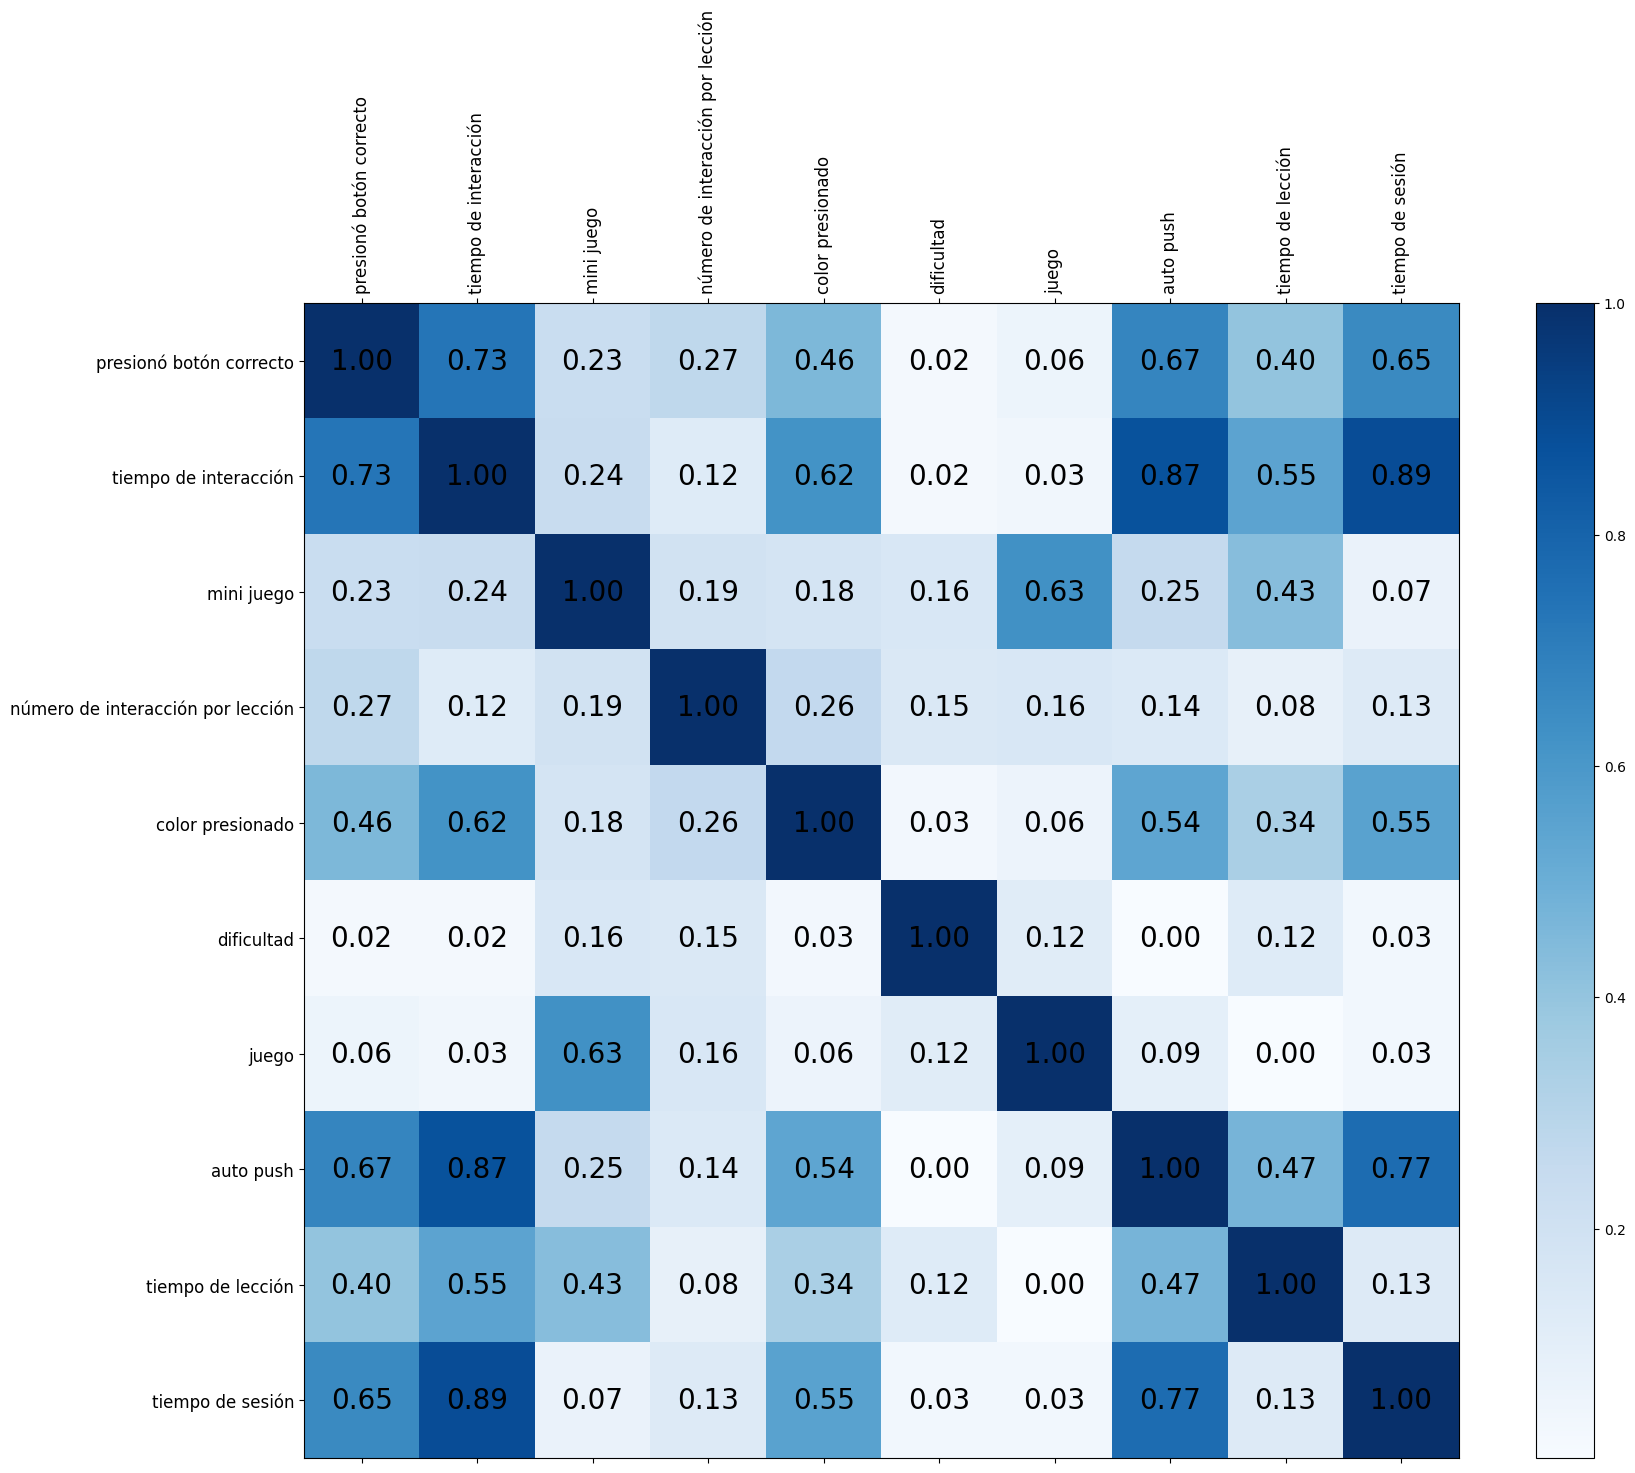

In [6]:
fig, ax = plt.subplots(figsize=(20, 15))
cax = ax.matshow(corr_Factors, cmap="Blues")
fig.colorbar(cax)

# Añadir anotaciones manualmente
for i in range(corr_Factors.shape[0]):
    for j in range(corr_Factors.shape[1]):
        ax.text(j, i, f"{corr_Factors.iloc[i, j]:.2f}", 
               ha="center", va="center", fontsize=20)

plt.xticks(range(len(corr_Factors.columns)), corr_Factors.columns, rotation=90, fontsize=12)
plt.yticks(range(len(corr_Factors.index)), corr_Factors.index, fontsize=12)
plt.show()

***Modelos lineales***

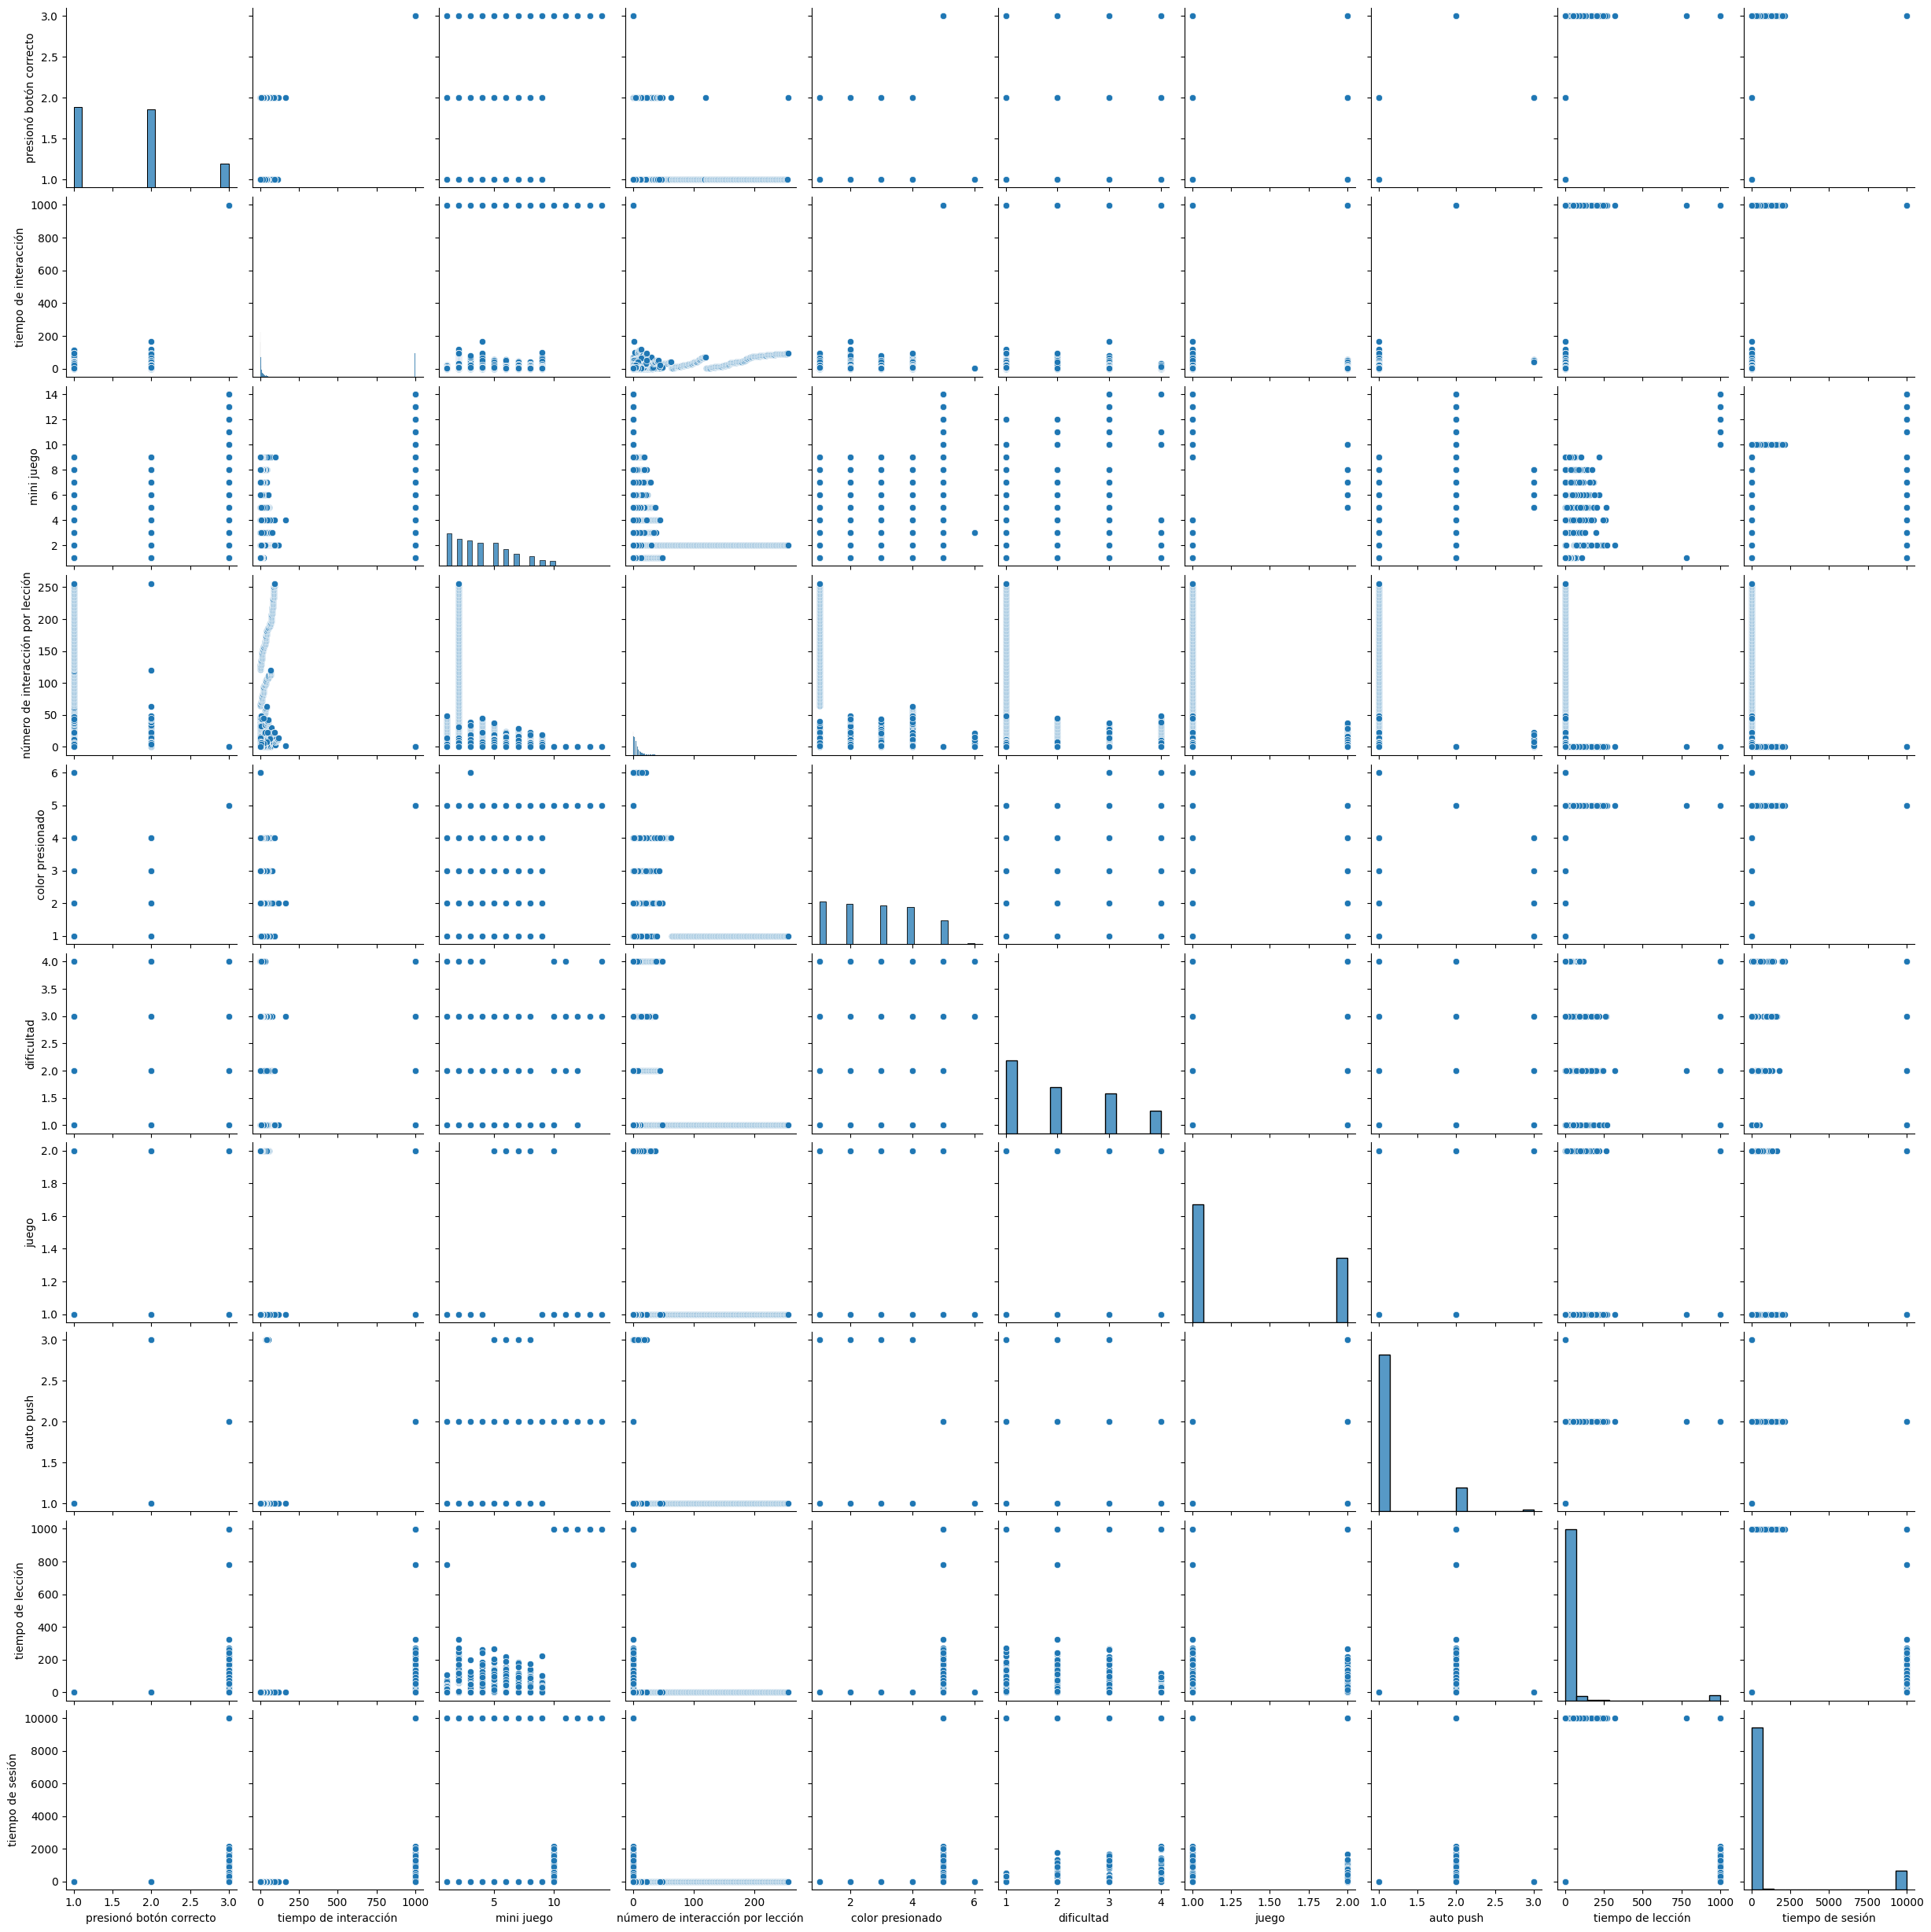

In [7]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df)

In [8]:
# Elegimos la columna objetivo
objetivo = 'presionó botón correcto'  # Cambia esto al nombre de tu variable objetivo

# Seleccionamos solo columnas numéricas
df_numericas = df.select_dtypes(include=['number'])

# Calculamos la matriz de correlación
correlaciones = df_numericas.corr()

***Lineal simple***

In [9]:
# Ordenamos las correlaciones del objetivo
mejor_variable = correlaciones[objetivo].drop(labels=[objetivo]).abs().idxmax()
mejor_correlacion = correlaciones.loc[mejor_variable, objetivo]

print(f"La mejor variable correlacionada con {objetivo} es {mejor_variable} con una correlación de {mejor_correlacion:.2f}")

La mejor variable correlacionada con presionó botón correcto es tiempo de interacción con una correlación de 0.73


***No lineal***

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Datos
X = df[[mejor_variable]].values
y = df[objetivo].values

# Ajustamos un modelo polinomial de grado 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

modelo_poly = LinearRegression()
modelo_poly.fit(X_poly, y)

# Predicciones
y_pred_poly = modelo_poly.predict(X_poly)

# Medimos qué tan bueno es el modelo
r2_poly = r2_score(y, y_pred_poly)
print(f"R² del modelo polinomial de grado 2: {r2_poly:.2f}")


R² del modelo polinomial de grado 2: 0.55


In [11]:
r2_lineal_simple = mejor_correlacion ** 2
print(f"R² de la correlación lineal simple: {r2_lineal_simple:.2f}")

R² de la correlación lineal simple: 0.54


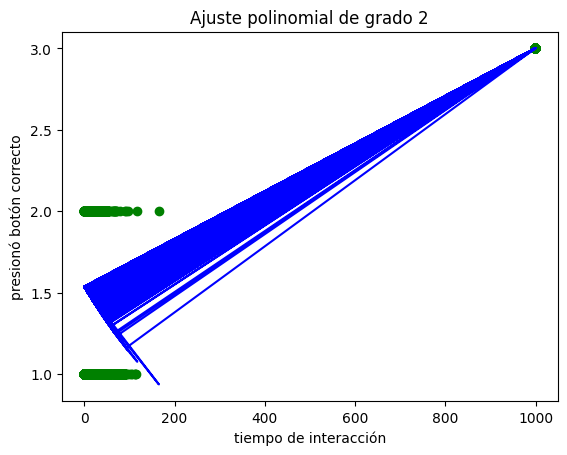

In [12]:
# Gráfica de dispersión
plt.scatter(X, y, color='green')
plt.plot(X, y_pred_poly, color='blue')
plt.xlabel(mejor_variable)
plt.ylabel(objetivo)
plt.title('Ajuste polinomial de grado 2')
plt.show()


#### Erick Osvaldo

variables como objetivo: “tiempo de interacción”, “botón correcto” “color presionado” y “dificultad” ,

In [13]:
df = pd.read_csv('Erick Osvaldo.csv')
#Eliminamos la columna de fecha
df1 = df.copy()
df1 = df1.drop(columns=['fecha', 'administrador', 'usuario', 'juego'])
df1.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Erick Osvaldo.csv'

***Correlación***

In [ ]:
corr_FactorsEO = df1.corr()
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.773739,-0.597832,0.011635,0.228332,-0.071693,0.733947,-0.017766,0.769584
tiempo de interacción,0.773739,1.000000,-0.683488,-0.086613,0.633392,-0.457613,0.905720,0.131247,0.973682
mini juego,-0.597832,-0.683488,1.000000,-0.072876,-0.534526,-0.164215,-0.593470,-0.113105,-0.611540
número de interacción por lección,0.011635,-0.086613,-0.072876,1.000000,0.033698,0.296551,-0.340876,-0.407939,-0.019696
color presionado,0.228332,0.633392,-0.534526,0.033698,1.000000,-0.540746,0.450254,-0.030548,0.636260
dificultad,-0.071693,-0.457613,-0.164215,0.296551,-0.540746,1.000000,-0.496150,-0.137860,-0.472953
auto push,0.733947,0.905720,-0.593470,-0.340876,0.450254,-0.496150,1.000000,0.152391,0.876500
tiempo de lección,-0.017766,0.131247,-0.113105,-0.407939,-0.030548,-0.137860,0.152391,1.000000,-0.087560
tiempo de sesión,0.769584,0.973682,-0.611540,-0.019696,0.636260,-0.472953,0.876500,-0.087560,1.000000


In [ ]:
corr_FactorsEO= abs(corr_FactorsEO)
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.773739,0.597832,0.011635,0.228332,0.071693,0.733947,0.017766,0.769584
tiempo de interacción,0.773739,1.000000,0.683488,0.086613,0.633392,0.457613,0.905720,0.131247,0.973682
mini juego,0.597832,0.683488,1.000000,0.072876,0.534526,0.164215,0.593470,0.113105,0.611540
número de interacción por lección,0.011635,0.086613,0.072876,1.000000,0.033698,0.296551,0.340876,0.407939,0.019696
color presionado,0.228332,0.633392,0.534526,0.033698,1.000000,0.540746,0.450254,0.030548,0.636260
dificultad,0.071693,0.457613,0.164215,0.296551,0.540746,1.000000,0.496150,0.137860,0.472953
auto push,0.733947,0.905720,0.593470,0.340876,0.450254,0.496150,1.000000,0.152391,0.876500
tiempo de lección,0.017766,0.131247,0.113105,0.407939,0.030548,0.137860,0.152391,1.000000,0.087560
tiempo de sesión,0.769584,0.973682,0.611540,0.019696,0.636260,0.472953,0.876500,0.087560,1.000000


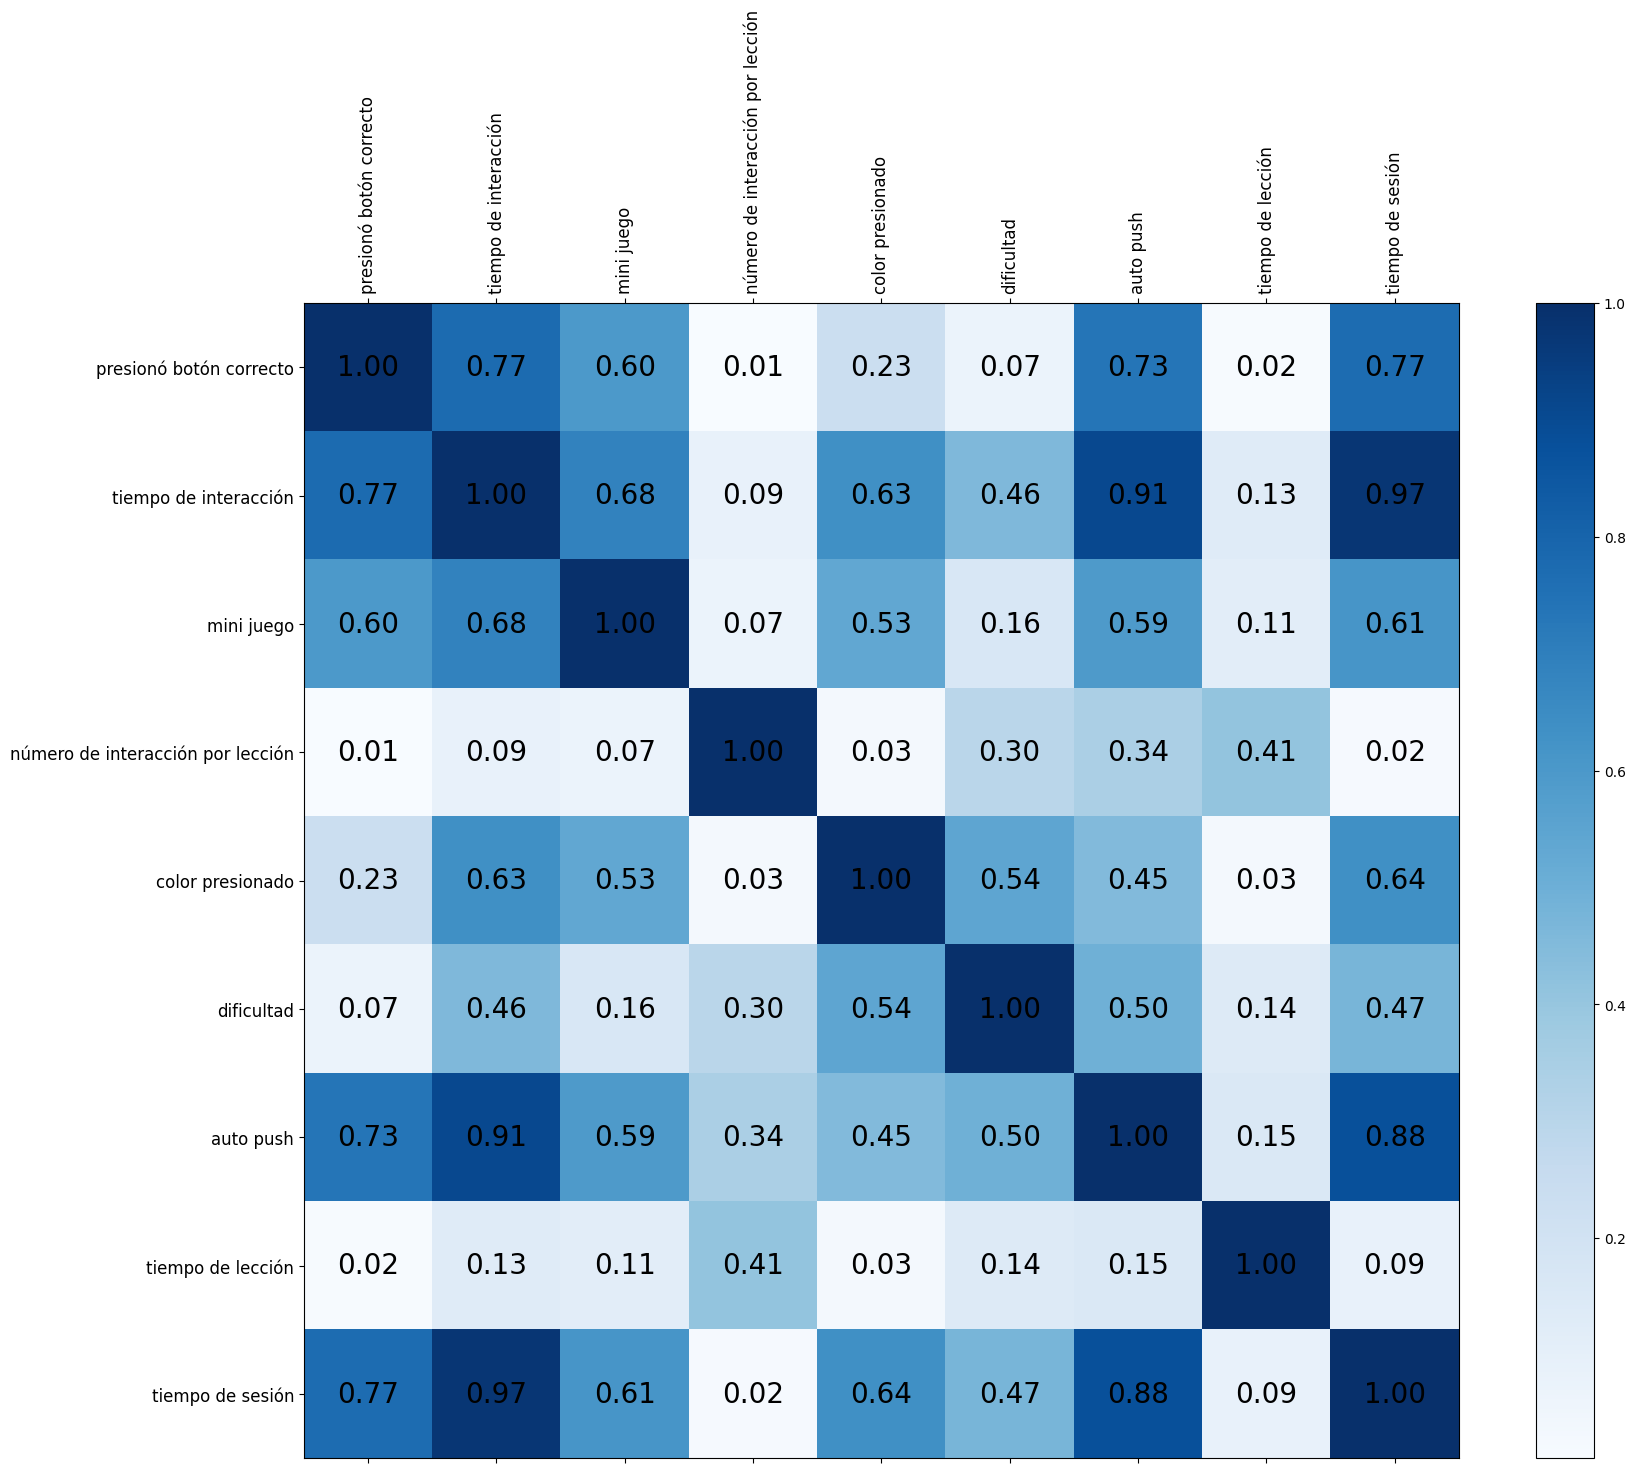

In [ ]:
fig, ax = plt.subplots(figsize=(20, 15))
cax = ax.matshow(corr_FactorsEO, cmap="Blues")
fig.colorbar(cax)

# Añadir anotaciones manualmente
for i in range(corr_FactorsEO.shape[0]):
    for j in range(corr_FactorsEO.shape[1]):
        ax.text(j, i, f"{corr_FactorsEO.iloc[i, j]:.2f}", 
               ha="center", va="center", fontsize=20)

plt.xticks(range(len(corr_FactorsEO.columns)), corr_FactorsEO.columns, rotation=90, fontsize=12)
plt.yticks(range(len(corr_FactorsEO.index)), corr_FactorsEO.index, fontsize=12)
plt.show()

***Modelos no lineales para Erick Osvaldo***

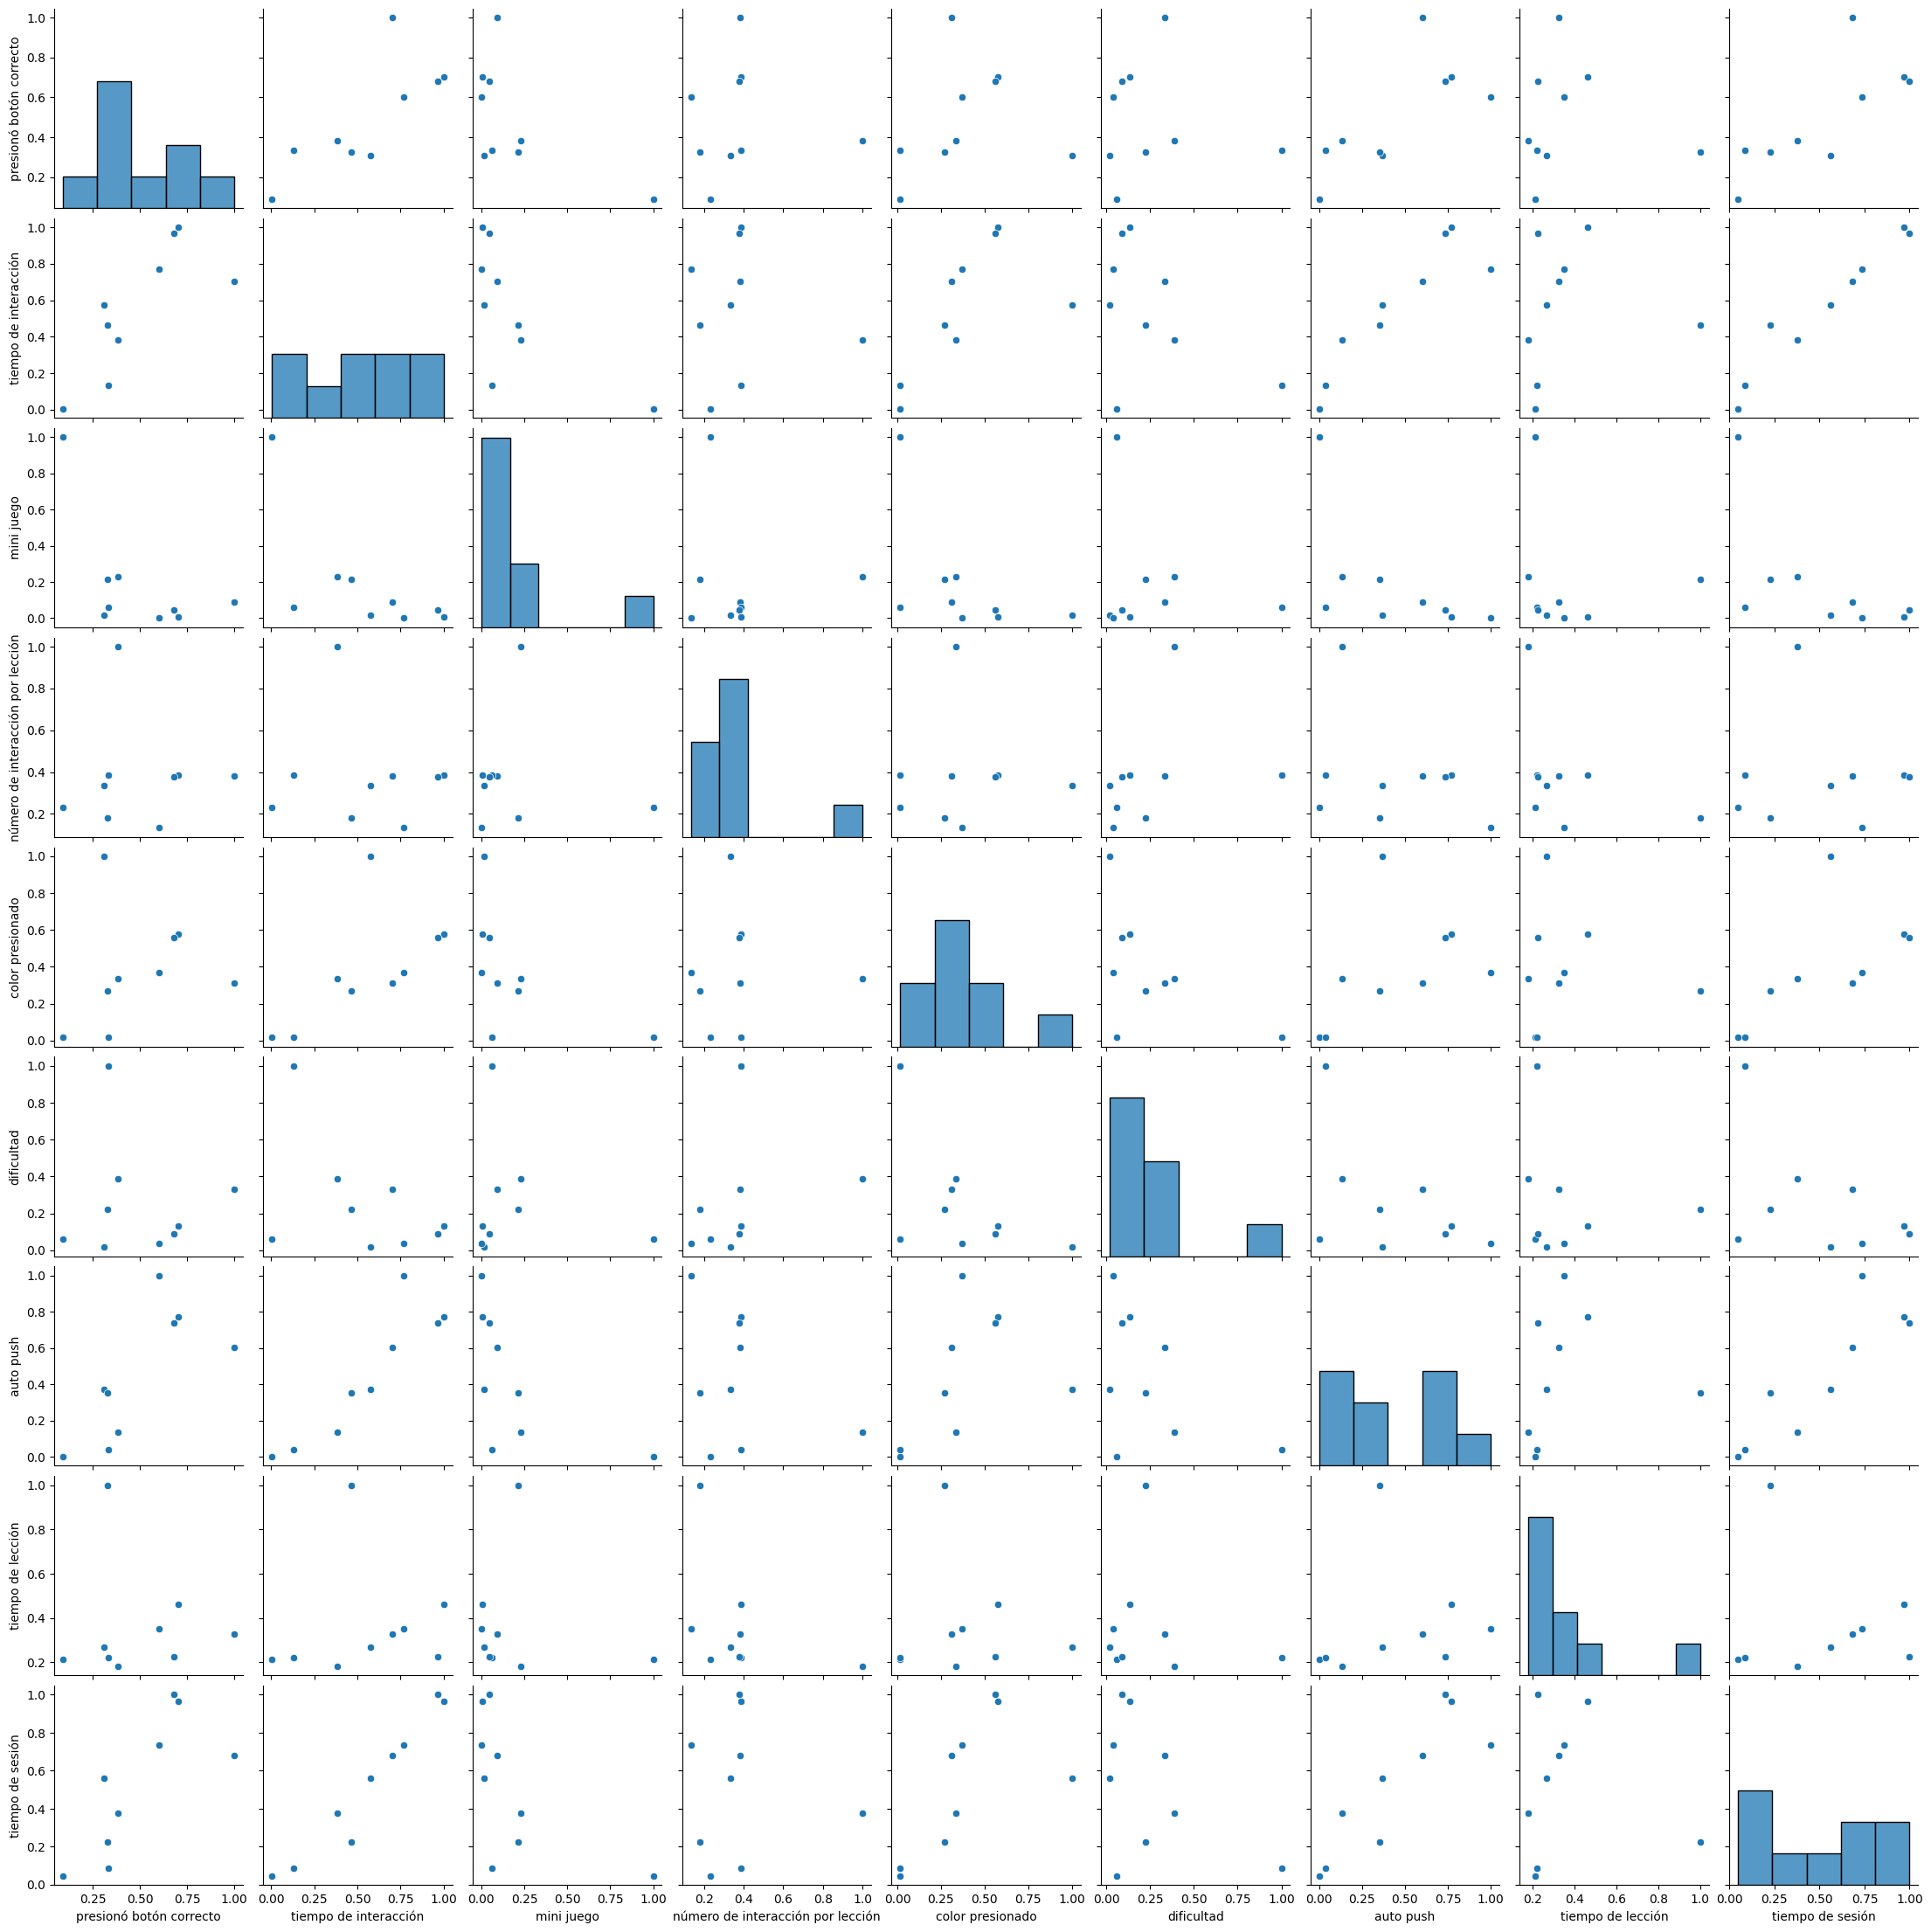

In [ ]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df1)

#### Modelo 1 (tiempo de interacción)

In [ ]:
#Eliminamos los datos nulos de la coumna
EO = df1[df1['presionó botón correcto'] < 3]

In [ ]:
EO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
2,1.000000,0.704634,0.090289,0.382233,0.309919,0.332413,0.603290,0.326378,0.681284
3,0.704634,1.000000,0.005848,0.384249,0.575176,0.132325,0.769989,0.463142,0.966768
4,0.090289,0.005848,1.000000,0.230948,0.016448,0.060044,0.000136,0.212513,0.046137
5,0.382233,0.384249,0.230948,1.000000,0.334292,0.385648,0.133348,0.181478,0.378819
6,0.309919,0.575176,0.016448,0.334292,1.000000,0.017594,0.370077,0.267938,0.559297
7,0.332413,0.132325,0.060044,0.385648,0.017594,1.000000,0.038135,0.222467,0.087092
10,0.603290,0.769989,0.000136,0.133348,0.370077,0.038135,1.000000,0.352847,0.736537
11,0.326378,0.463142,0.212513,0.181478,0.267938,0.222467,0.352847,1.000000,0.224598
12,0.681284,0.966768,0.046137,0.378819,0.559297,0.087092,0.736537,0.224598,1.000000


In [ ]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= EO[['presionó botón correcto']]
Var_Dep= EO['tiempo de interacción']

In [ ]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [ ]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [ ]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, EO['presionó botón correcto'], EO['tiempo de interacción'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([-1.87574996,  3.02130235, -0.34962049])

In [ ]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,presionó botón correcto
2,0.795932
3,0.847965
4,-0.092122
5,0.531170
6,0.406573


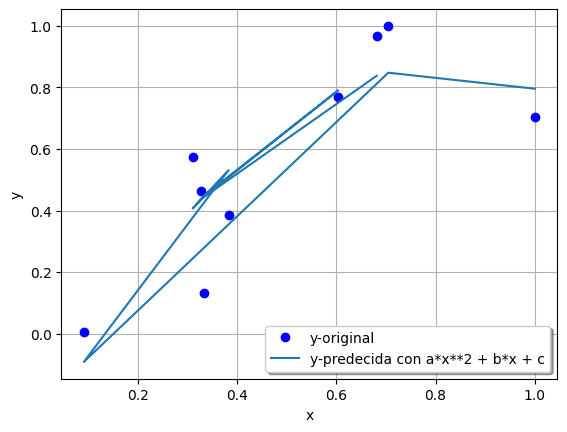

In [ ]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [ ]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.7820402840252254

In [ ]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.8843304156395535)

Esto significa que no son dependientes una de la otra en absoluto

## Modelo 2 (presionó botón correcto)

In [ ]:
EO = df1[df1['auto push'] != 0]

In [ ]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= EO[['auto push']]
Var_Dep= df1['presionó botón correcto']

In [ ]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [ ]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [ ]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, EO['presionó botón correcto'], EO['auto push'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

ValueError: array must not contain infs or NaNs

In [ ]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,auto push
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


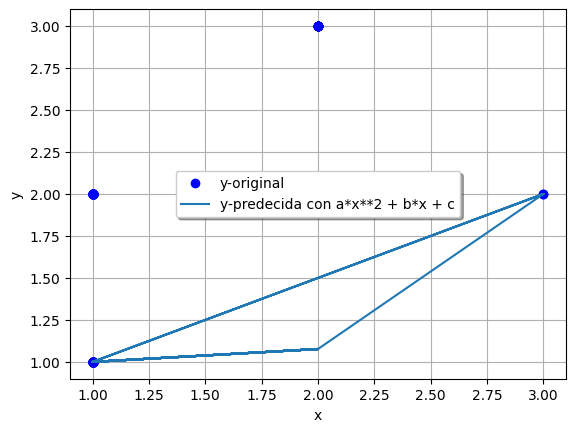

In [ ]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show()

In [ ]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

C:\Users\italy\AppData\Local\Temp\ipykernel_20312\3582695773.py:4: RuntimeWarning: invalid value encountered in sqrt
  R = np.sqrt(R2_Modelo1)


-0.7603550295857975

In [ ]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

C:\Users\italy\AppData\Local\Temp\ipykernel_20312\563892453.py:2: RuntimeWarning: invalid value encountered in sqrt
  R = np.sqrt(R2_Modelo1)


np.float64(nan)

## Modelo 3 (color presionado)

In [ ]:
#Eliminamos los datos nulos de la coumna
EO = df1[df1['color presionado'] != 5]
EO = df1[df1['tiempo de interacción'] != 999.0]

In [ ]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= EO[['tiempo de interacción']]
Var_Dep= EO['color presionado']

In [ ]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [ ]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [ ]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, EO['tiempo de interacción'], EO['color presionado'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([-1.81220789e-04, -6.79365595e-03,  2.66917792e+00])

In [ ]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,tiempo de interacción
0,2.669178
1,2.618578
2,2.560989
3,2.498697
4,2.462673


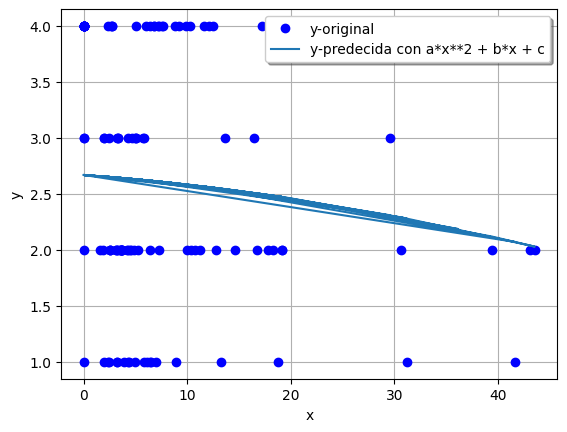

In [ ]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [ ]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.01399528075607015

In [ ]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.11830165153568292)

## Modelo 4 (dificultad)

De esta coolumna no es necesario borrar los datos porque no sabemos con exactitud que datos son los nulos

In [ ]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= df1['tiempo de lección']
Var_Dep= df1['dificultad']

In [ ]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [ ]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [ ]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, df1['presionó botón correcto'], df1['tiempo de lección'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([  69.08061969, -207.24186049,  138.16124145])

In [ ]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

0    138.161241
1    138.161241
2    138.161241
3    138.161241
4    138.161241
Name: tiempo de lección, dtype: float64

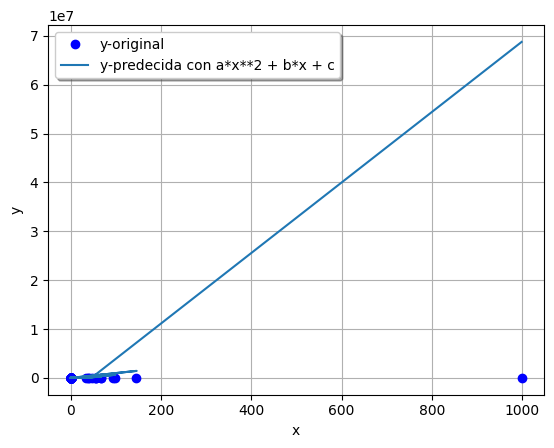

In [ ]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [ ]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

C:\Users\italy\AppData\Local\Temp\ipykernel_20312\3582695773.py:4: RuntimeWarning: invalid value encountered in sqrt
  R = np.sqrt(R2_Modelo1)


-47651848397434.55

In [ ]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

C:\Users\italy\AppData\Local\Temp\ipykernel_20312\563892453.py:2: RuntimeWarning: invalid value encountered in sqrt
  R = np.sqrt(R2_Modelo1)


np.float64(nan)

#### Esmeralda

In [236]:
df = pd.read_csv('Esmeralda.csv')
#Eliminamos la columna de fecha
df1 = df.copy()
df1 = df1.drop(columns=['usuario', 'juego', 'Unnamed: 0'])
df1.head()

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
0,2,4.604386,9,1,4,1,1,0.00000,0.0
1,2,3.917116,9,2,2,1,1,0.00000,0.0
2,2,2.199356,9,3,3,1,1,0.00000,0.0
3,2,2.982496,9,4,1,1,1,0.00000,0.0
4,3,999.000000,9,0,5,1,2,28.79073,9999.0


***Correlación***

In [15]:
corr_FactorsEO = df1.corr()
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.867480,0.146923,-0.671642,0.794069,NaN,0.870388,0.367500,0.779760
tiempo de interacción,0.867480,1.000000,0.101907,-0.702518,0.801930,NaN,0.999937,0.422199,0.895820
mini juego,0.146923,0.101907,1.000000,-0.127056,0.170392,NaN,0.104496,0.396834,-0.077900
número de interacción por lección,-0.671642,-0.702518,-0.127056,1.000000,-0.760695,NaN,-0.705279,-0.297787,-0.631842
color presionado,0.794069,0.801930,0.170392,-0.760695,1.000000,NaN,0.804984,0.339885,0.721166
dificultad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
auto push,0.870388,0.999937,0.104496,-0.705279,0.804984,NaN,1.000000,0.422225,0.895876
tiempo de lección,0.367500,0.422199,0.396834,-0.297787,0.339885,NaN,0.422225,1.000000,-0.024079
tiempo de sesión,0.779760,0.895820,-0.077900,-0.631842,0.721166,NaN,0.895876,-0.024079,1.000000


In [16]:
corr_FactorsEO= abs(corr_FactorsEO)
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.867480,0.146923,0.671642,0.794069,NaN,0.870388,0.367500,0.779760
tiempo de interacción,0.867480,1.000000,0.101907,0.702518,0.801930,NaN,0.999937,0.422199,0.895820
mini juego,0.146923,0.101907,1.000000,0.127056,0.170392,NaN,0.104496,0.396834,0.077900
número de interacción por lección,0.671642,0.702518,0.127056,1.000000,0.760695,NaN,0.705279,0.297787,0.631842
color presionado,0.794069,0.801930,0.170392,0.760695,1.000000,NaN,0.804984,0.339885,0.721166
dificultad,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
auto push,0.870388,0.999937,0.104496,0.705279,0.804984,NaN,1.000000,0.422225,0.895876
tiempo de lección,0.367500,0.422199,0.396834,0.297787,0.339885,NaN,0.422225,1.000000,0.024079
tiempo de sesión,0.779760,0.895820,0.077900,0.631842,0.721166,NaN,0.895876,0.024079,1.000000


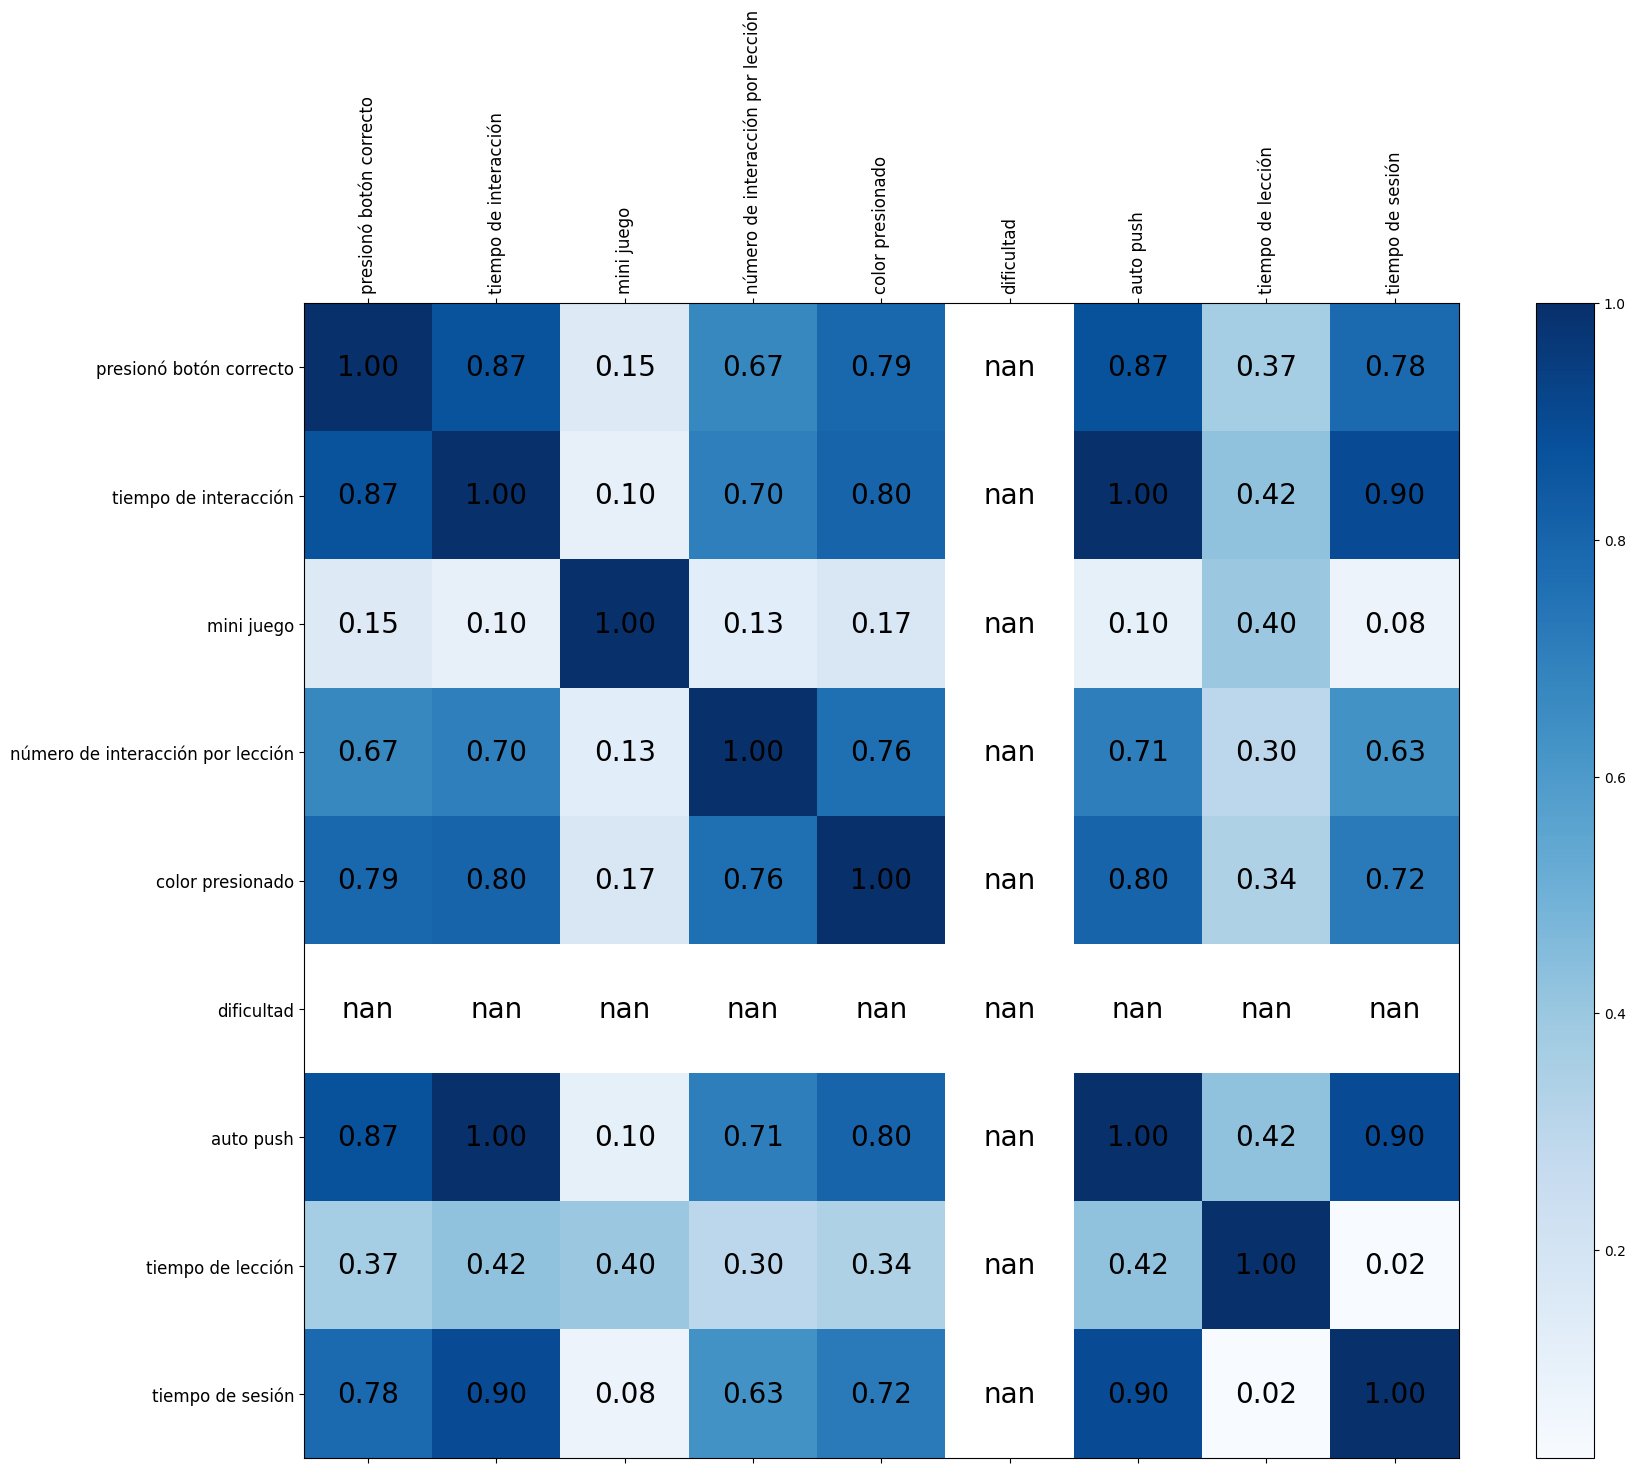

In [17]:
fig, ax = plt.subplots(figsize=(20, 15))
cax = ax.matshow(corr_FactorsEO, cmap="Blues")
fig.colorbar(cax)

# Añadir anotaciones manualmente
for i in range(corr_FactorsEO.shape[0]):
    for j in range(corr_FactorsEO.shape[1]):
        ax.text(j, i, f"{corr_FactorsEO.iloc[i, j]:.2f}", 
               ha="center", va="center", fontsize=20)

plt.xticks(range(len(corr_FactorsEO.columns)), corr_FactorsEO.columns, rotation=90, fontsize=12)
plt.yticks(range(len(corr_FactorsEO.index)), corr_FactorsEO.index, fontsize=12)
plt.show()

***Modelos no lineales para Esmeralda***

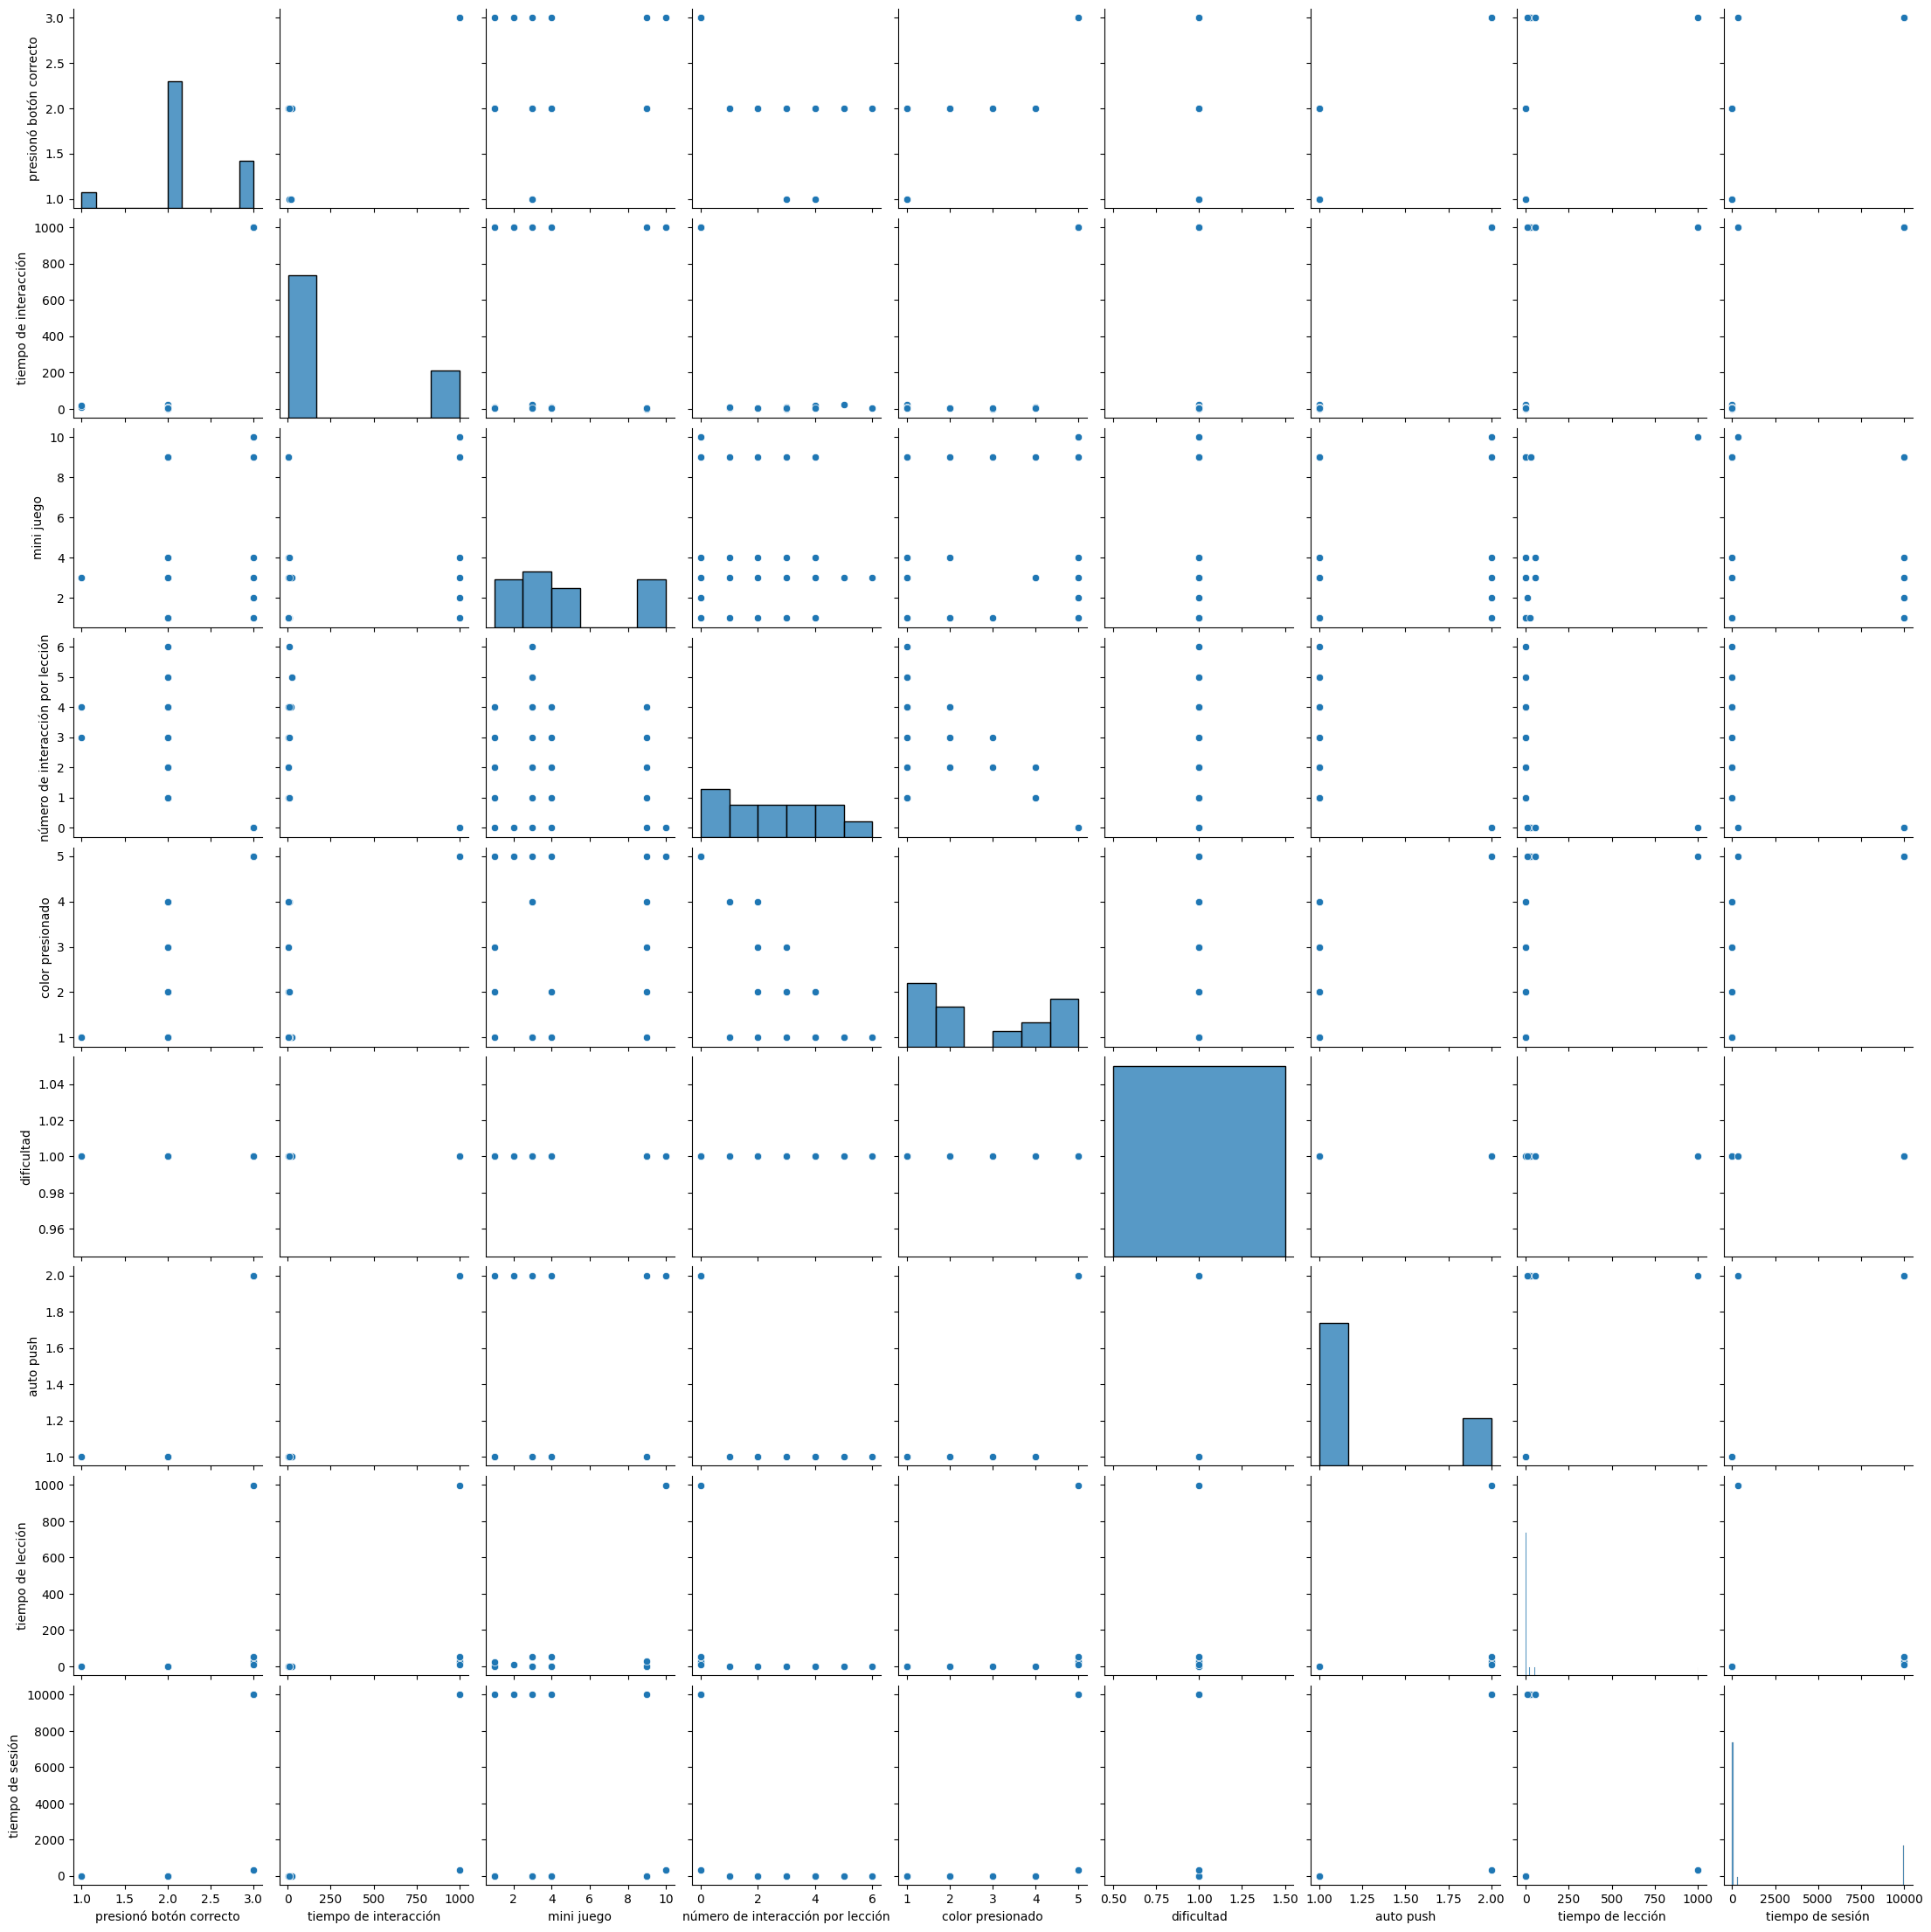

In [18]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df1)

#### Modelo 1 (tiempo de interacción)

In [19]:
#Eliminamos los datos nulos de la coumna
ES = df1[df1['presionó botón correcto'] < 3]

In [20]:
ES

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
0,2,4.604386,9,1,4,1,1,0.0,0.0
1,2,3.917116,9,2,2,1,1,0.0,0.0
2,2,2.199356,9,3,3,1,1,0.0,0.0
3,2,2.982496,9,4,1,1,1,0.0,0.0
5,2,7.897322,1,1,1,1,1,0.0,0.0
6,2,3.467021,1,2,3,1,1,0.0,0.0
7,2,3.950273,1,3,2,1,1,0.0,0.0
8,2,4.183996,1,4,2,1,1,0.0,0.0
10,2,7.154699,3,1,4,1,1,0.0,0.0
11,2,4.933453,3,2,4,1,1,0.0,0.0


In [21]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= ES[['presionó botón correcto']]
Var_Dep= ES['tiempo de interacción']

In [22]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [23]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [24]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, ES['presionó botón correcto'], ES['tiempo de interacción'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([  58.01290572, -183.18005104,  140.93358532])

In [25]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,presionó botón correcto
0,6.625106
1,6.625106
2,6.625106
3,6.625106
5,6.625106


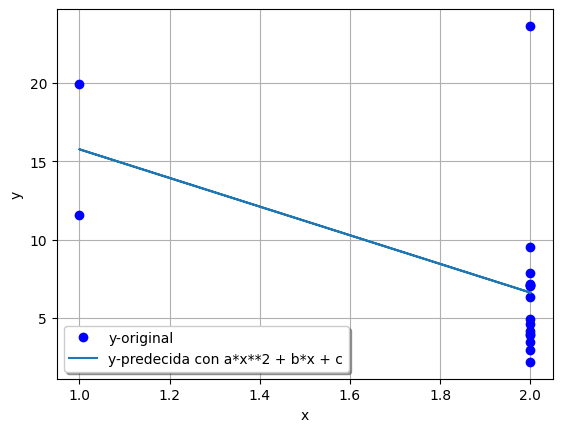

In [26]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [27]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.2681262895733708

In [28]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.5178091246524831)

#### Modelo 2 (presionó botón correcto)

In [192]:
ES = df1[df1['presionó botón correcto'] != 3]

In [193]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= ES[['color presionado']]
Var_Dep= ES['presionó botón correcto']

In [194]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [195]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [196]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, ES['color presionado'], ES['presionó botón correcto'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([-0.07274969,  0.44143033,  1.38594328])

In [197]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,color presionado
0,1.987670
1,1.977805
2,2.055487
3,1.754624
5,1.754624


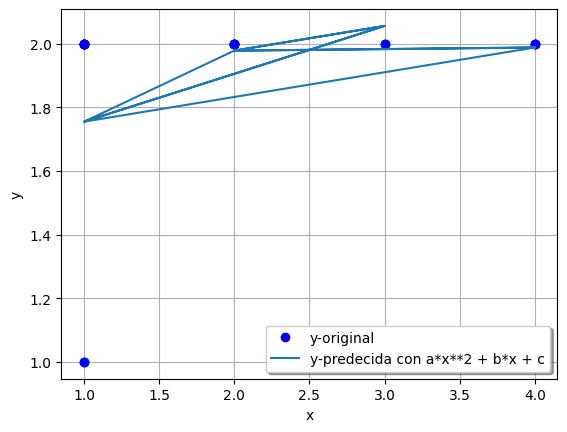

In [198]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show()

In [199]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.15104808877928488

In [200]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.38864905606380273)

#### Modelo 3 (color presionado)

In [237]:
#Eliminamos los datos nulos de la coumna
ES = df1[df1['color presionado'] != 5] 
ES = df1[df1['tiempo de interacción'] != 999.0]

In [238]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= ES[['tiempo de interacción']]
Var_Dep= ES['color presionado']

In [239]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [240]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [241]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, ES['tiempo de interacción'], ES['color presionado'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([ 0.00646988, -0.25316675,  3.35752474])

In [242]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,tiempo de interacción
0,2.329011
1,2.465114
2,2.832017
3,2.660007
5,1.761697


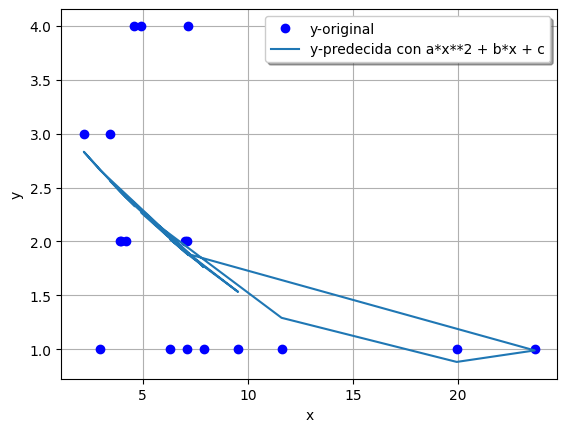

In [243]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [244]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.2416867011990398

In [245]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.4916164167306049)

#### Modelo 4 (Dificultad)

De esta coolumna no es necesario borrar los datos porque no sabemos con exactitud que datos son los nulos

In [254]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= df1['mini juego']
Var_Dep= df1['dificultad']

In [255]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [256]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [257]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, df1['mini juego'], df1['dificultad'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

/var/folders/6g/_xkwmvhx4_sg_spcn348_2wc0000gn/T/ipykernel_2619/3572606919.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  parametros1, covs= curve_fit(func1, df1['mini juego'], df1['dificultad'])


array([1.11022302e-15, 2.22044605e-16, 1.00000000e+00])

In [258]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: mini juego, dtype: float64

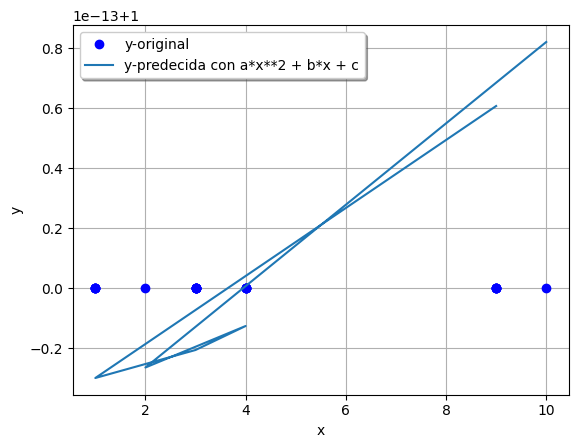

In [259]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [260]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.0

In [261]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.0)

#### Ingrid

In [262]:
df = pd.read_csv('Ingrid.csv')
#Eliminamos la columna de fecha
df1 = df.copy()
df1 = df1.drop(columns=['usuario', 'juego', 'Unnamed: 0', 'fecha', 'administrador'])
df1.head()

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
0,1,0.674964,8,1,3,1,1,0.0,0.0
1,2,0.691902,8,2,4,1,1,0.0,0.0
2,2,15.867730,8,3,2,1,1,0.0,0.0
3,1,30.535140,8,4,2,1,1,0.0,0.0
4,2,41.319240,8,5,3,1,3,0.0,0.0


***Correlación***

In [263]:
corr_FactorsEO = df1.corr()
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.767810,0.356997,-0.388686,0.650469,0.173232,0.597433,0.445392,0.654818
tiempo de interacción,0.767810,1.000000,0.466824,-0.543905,0.749738,0.218231,0.657099,0.582412,0.856266
mini juego,0.356997,0.466824,1.000000,-0.259974,0.350221,0.394445,0.301702,0.988656,-0.056267
número de interacción por lección,-0.388686,-0.543905,-0.259974,1.000000,-0.455324,-0.066715,-0.165536,-0.324345,-0.476854
color presionado,0.650469,0.749738,0.350221,-0.455324,1.000000,0.050902,0.630714,0.436938,0.642389
dificultad,0.173232,0.218231,0.394445,-0.066715,0.050902,1.000000,0.061888,0.388551,0.017694
auto push,0.597433,0.657099,0.301702,-0.165536,0.630714,0.061888,1.000000,0.376405,0.553393
tiempo de lección,0.445392,0.582412,0.988656,-0.324345,0.436938,0.388551,0.376405,1.000000,0.080911
tiempo de sesión,0.654818,0.856266,-0.056267,-0.476854,0.642389,0.017694,0.553393,0.080911,1.000000


In [264]:
corr_FactorsEO= abs(corr_FactorsEO)
corr_FactorsEO

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
presionó botón correcto,1.000000,0.767810,0.356997,0.388686,0.650469,0.173232,0.597433,0.445392,0.654818
tiempo de interacción,0.767810,1.000000,0.466824,0.543905,0.749738,0.218231,0.657099,0.582412,0.856266
mini juego,0.356997,0.466824,1.000000,0.259974,0.350221,0.394445,0.301702,0.988656,0.056267
número de interacción por lección,0.388686,0.543905,0.259974,1.000000,0.455324,0.066715,0.165536,0.324345,0.476854
color presionado,0.650469,0.749738,0.350221,0.455324,1.000000,0.050902,0.630714,0.436938,0.642389
dificultad,0.173232,0.218231,0.394445,0.066715,0.050902,1.000000,0.061888,0.388551,0.017694
auto push,0.597433,0.657099,0.301702,0.165536,0.630714,0.061888,1.000000,0.376405,0.553393
tiempo de lección,0.445392,0.582412,0.988656,0.324345,0.436938,0.388551,0.376405,1.000000,0.080911
tiempo de sesión,0.654818,0.856266,0.056267,0.476854,0.642389,0.017694,0.553393,0.080911,1.000000


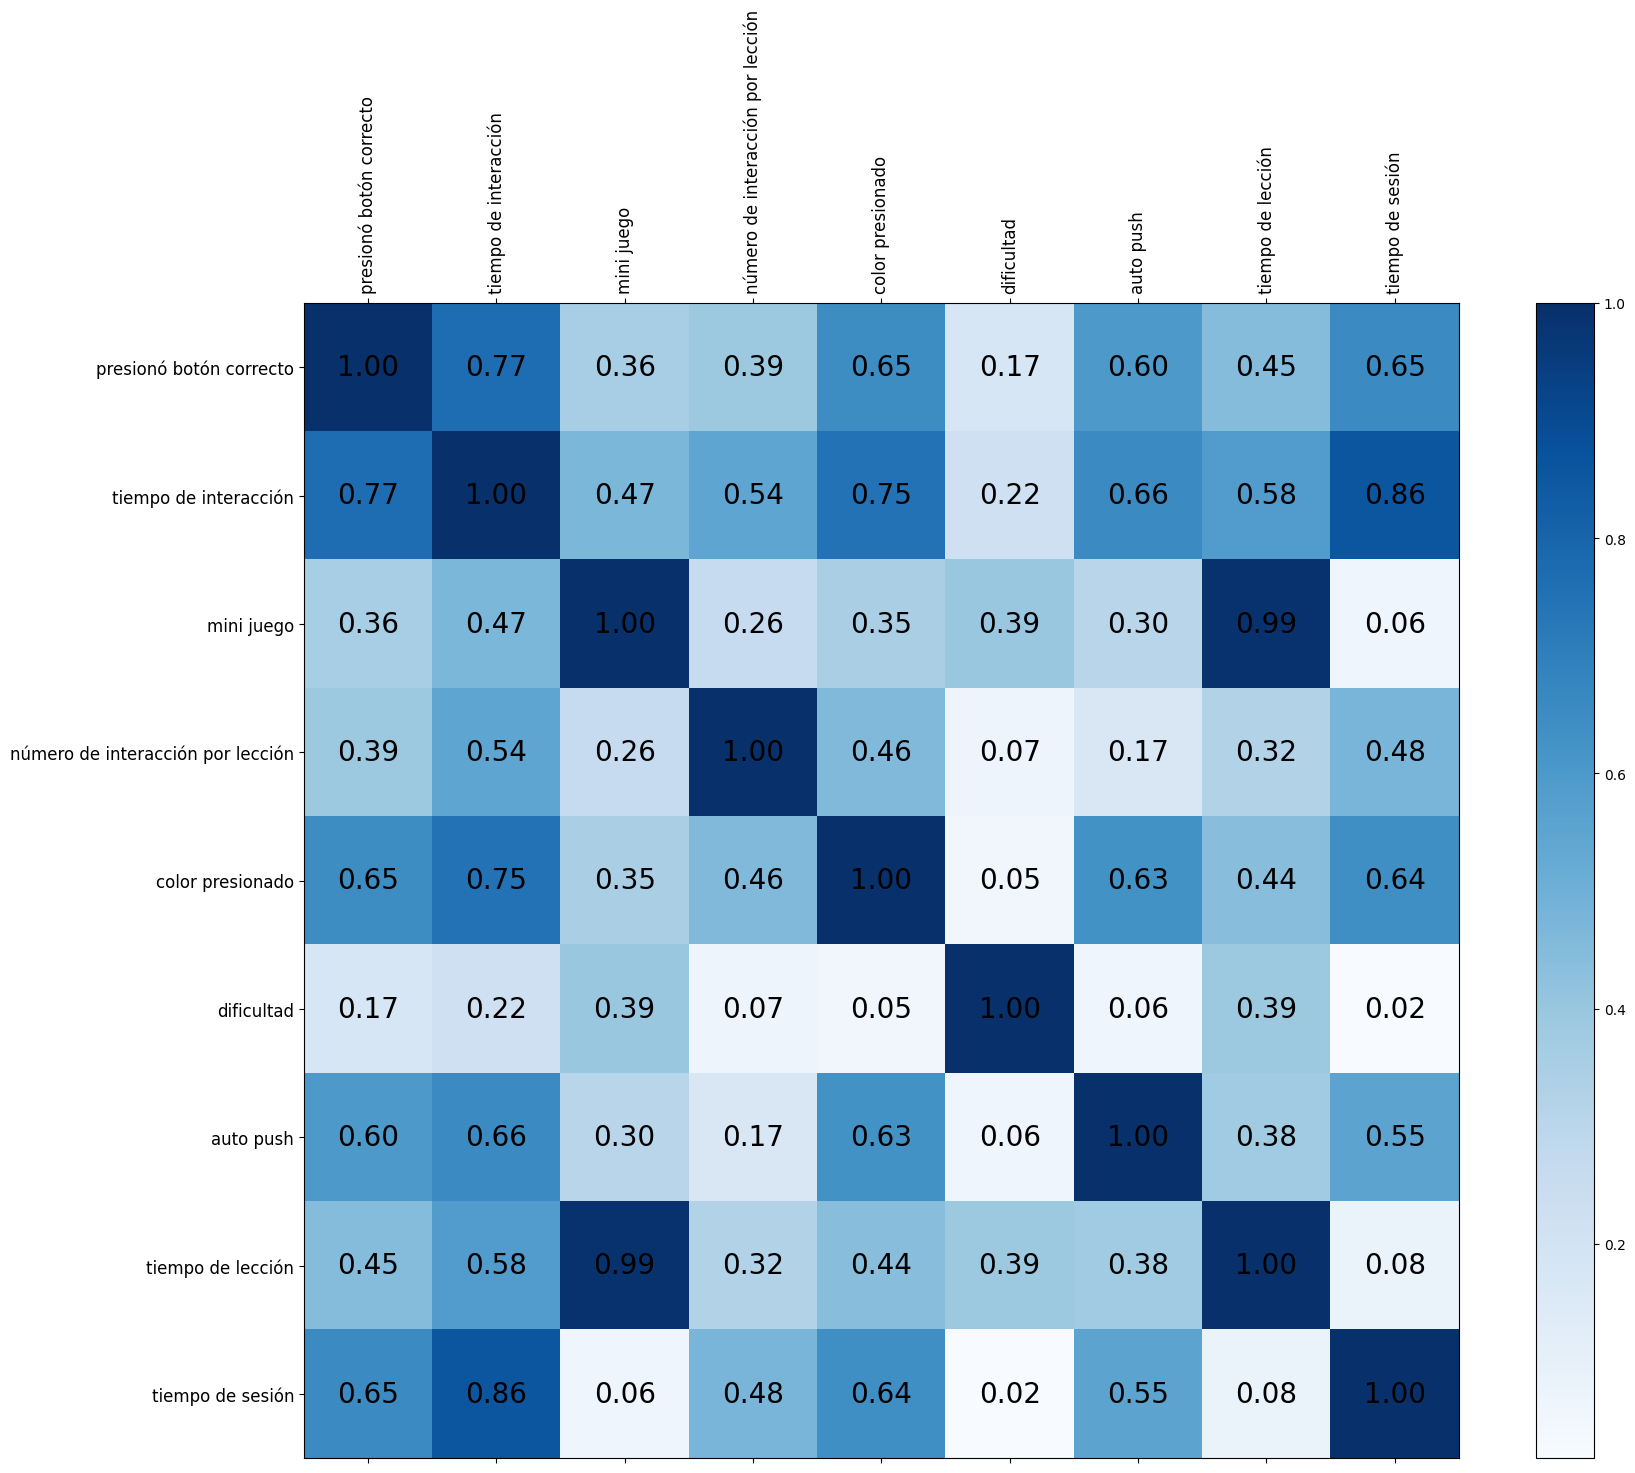

In [265]:
fig, ax = plt.subplots(figsize=(20, 15))
cax = ax.matshow(corr_FactorsEO, cmap="Blues")
fig.colorbar(cax)

# Añadir anotaciones manualmente
for i in range(corr_FactorsEO.shape[0]):
    for j in range(corr_FactorsEO.shape[1]):
        ax.text(j, i, f"{corr_FactorsEO.iloc[i, j]:.2f}", 
               ha="center", va="center", fontsize=20)

plt.xticks(range(len(corr_FactorsEO.columns)), corr_FactorsEO.columns, rotation=90, fontsize=12)
plt.yticks(range(len(corr_FactorsEO.index)), corr_FactorsEO.index, fontsize=12)
plt.show()

***Modelos no lineales para Ingrid***

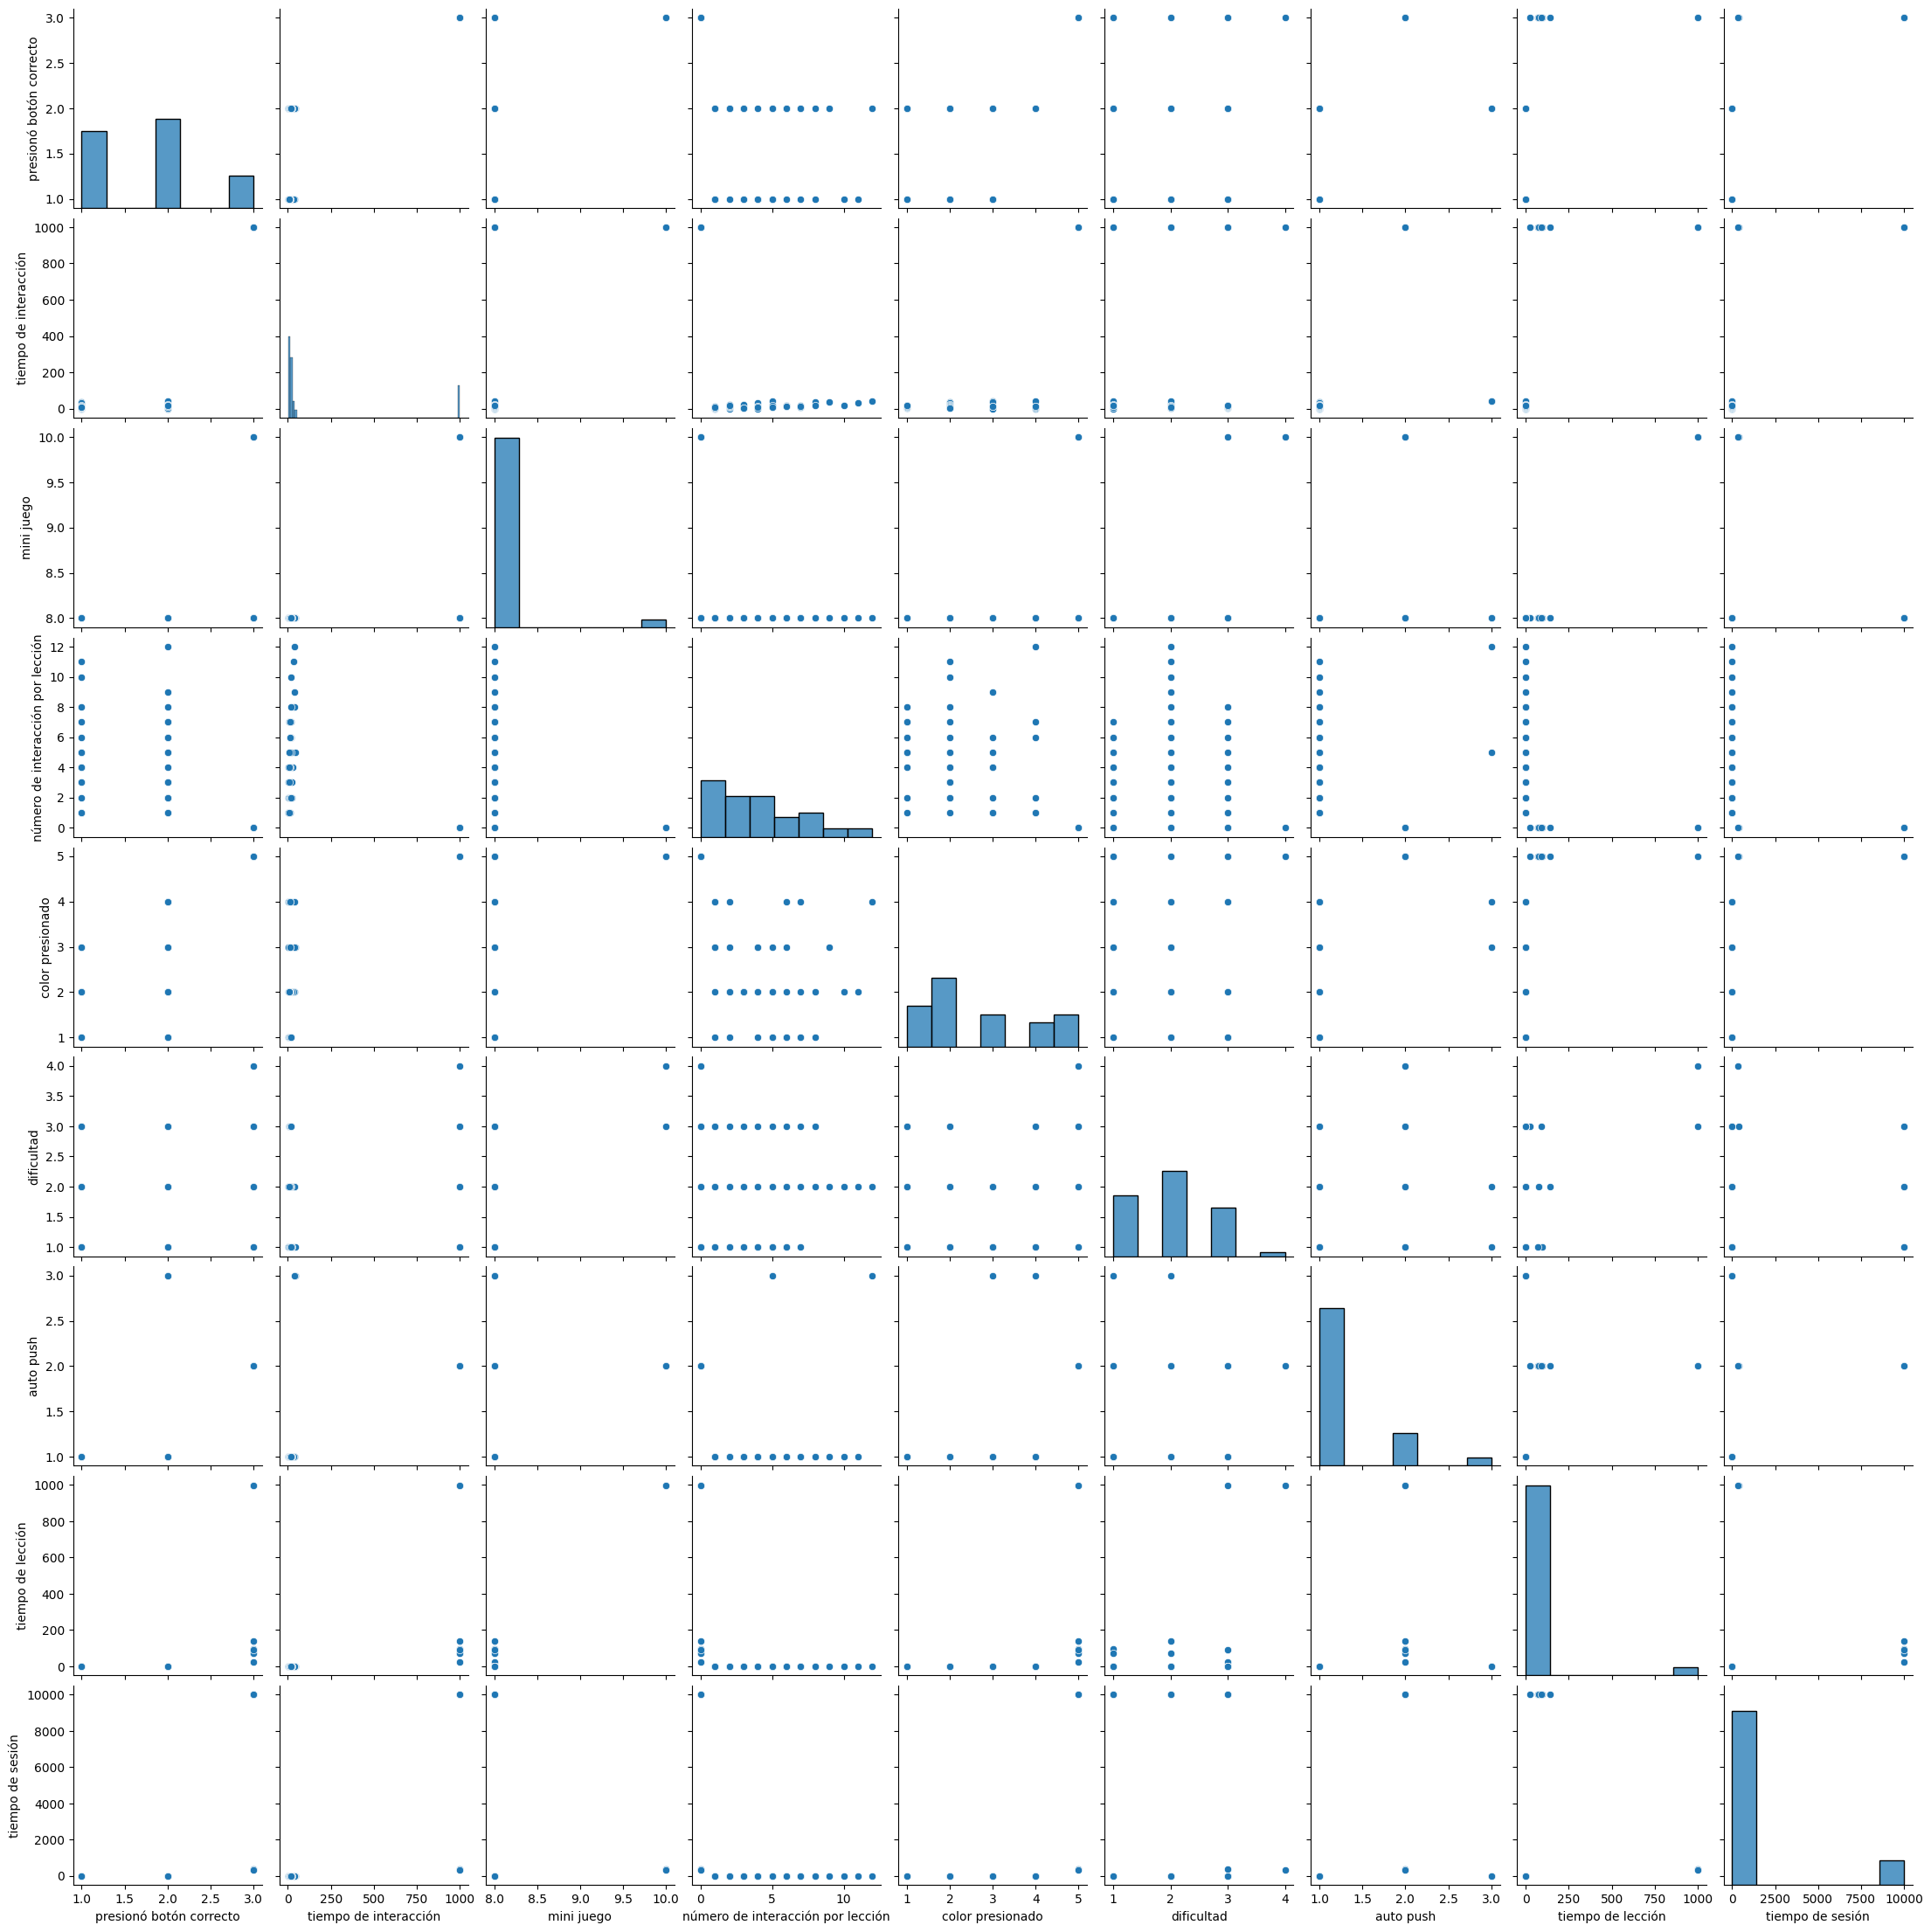

In [266]:
#Graficamos todas las dispersiones entre todas las variables
sns.pairplot(df1)

#### Modelo 1 (tiempo de interacción)

In [267]:
#Eliminamos los datos nulos de la coumna
IN = df1[df1['presionó botón correcto'] < 3]

In [268]:
IN.head()

,presionó botón correcto,tiempo de interacción,mini juego,número de interacción por lección,color presionado,dificultad,auto push,tiempo de lección,tiempo de sesión
0,1,0.674964,8,1,3,1,1,0.0,0.0
1,2,0.691902,8,2,4,1,1,0.0,0.0
2,2,15.867730,8,3,2,1,1,0.0,0.0
3,1,30.535140,8,4,2,1,1,0.0,0.0
4,2,41.319240,8,5,3,1,3,0.0,0.0


In [269]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= IN[['presionó botón correcto']]
Var_Dep= IN['tiempo de interacción']

In [270]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [271]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [272]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, IN['presionó botón correcto'], IN['tiempo de interacción'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([ -58.24027356,  179.2199837 , -108.59816311])

In [273]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,presionó botón correcto
0,12.381547
1,16.880710
2,16.880710
3,12.381547
4,16.880710


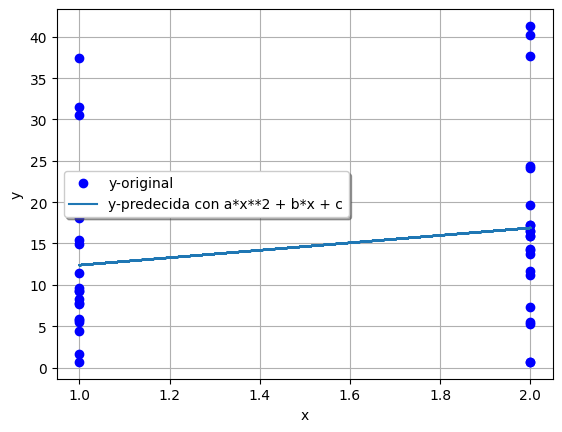

In [274]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [275]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.04322565566783676

In [276]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.20790780569241926)

#### Modelo 2 (presionó botón correcto)

In [210]:
IN = df1[df1['presionó botón correcto'] != 3]

In [211]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= IN[['color presionado']]
Var_Dep= IN['presionó botón correcto']

In [212]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [213]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [214]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, IN['color presionado'], IN['presionó botón correcto'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([ 0.23743302, -1.07246747,  2.51849962])

In [215]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,color presionado
0,1.437994
1,2.027558
2,1.323297
3,1.323297
4,1.437994


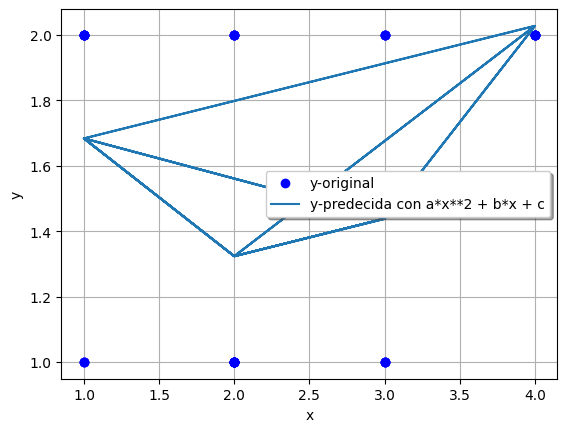

In [216]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show()

In [217]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.24650884966016373

In [218]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.49649657567818506)

#### Modelo 3 (color presionado)

In [165]:
#Eliminamos los datos nulos de la coumna
IN = df1[df1['color presionado'] != 5] 
IN = df1[df1['tiempo de interacción'] != 999.0]

In [166]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= IN[['tiempo de interacción']]
Var_Dep= IN['color presionado']

In [167]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [168]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [169]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, IN['tiempo de interacción'], IN['color presionado'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([ 0.00320761, -0.12918366,  3.0795623 ])

In [170]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

,tiempo de interacción
0,2.993829
1,2.991715
2,1.837338
3,2.125677
4,3.218073


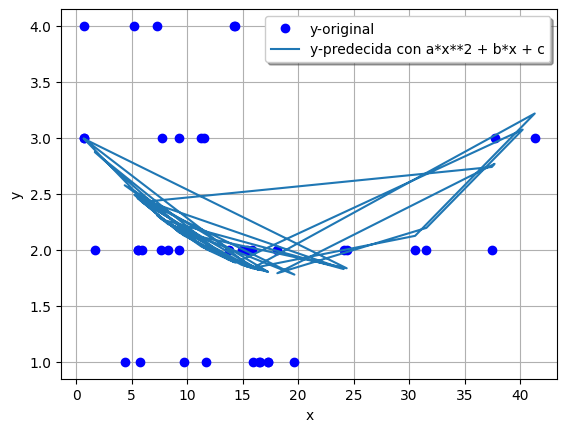

In [171]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [172]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.18389150670208498

In [173]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.42882572999073293)

#### Modelo 4 (Dificultad)

De esta coolumna no es necesario borrar los datos porque no sabemos con exactitud que datos son los nulos

In [174]:
#Declaramos las variables dependientes e independientes para la regresión No lineal
Vars_Indep= df1['mini juego']
Var_Dep= df1['dificultad']

In [175]:
#Redefinimos las variables 
x= Vars_Indep
y= Var_Dep

In [176]:
def  func1 (x, a, b, c):
     return a*x**2 + b*x + c

In [177]:
#Ajustamos los parámetros de la función curve_fit
parametros1, covs= curve_fit(func1, df1['mini juego'], df1['dificultad'])
#Obtenemos los coeficientes del modelo de regresión no lineal
parametros1

array([  37.26676346, -670.009189  , 2976.91554451])

In [178]:
# Predicciones
y_pred1 = func1(x, *parametros1)
#Calculamos las predicciones y reestructuramos el vector de predicciones
y_pred1.head()

0    1.914894
1    1.914894
2    1.914894
3    1.914894
4    1.914894
Name: mini juego, dtype: float64

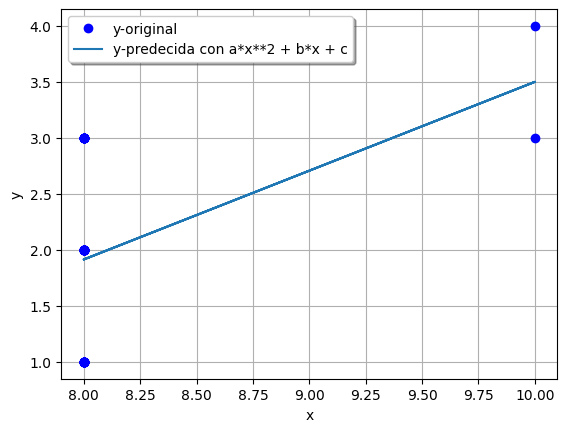

In [179]:
#Graficamos las predicciones y los datos originales para realizar la comparación
plt.plot(x, y, 'bo', label="y-original")
plt.plot(x, y_pred1, label="y-predecida con a*x**2 + b*x + c")
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='best', fancybox=True, shadow=True)
plt.grid(True)
plt.show() 

In [180]:
#Calculamos el coeficiente de determinación del modelo
R2_Modelo1 = r2_score(y, y_pred1)
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1) 
R2_Modelo1 

0.15558685840831987

In [181]:
#Calculamos el coeficiente de correlación del modelo
R = np.sqrt(R2_Modelo1)
R

np.float64(0.39444500048589776)